##### Hybrid Lorentz-ParT Masked Autoencoder for JetClass: GSoC 2026 Implementation

A complete notebook implementation of a **hybrid ParT + Lorentz-aware** model for JetClass-like ROOT data with:
- masked autoencoder pretraining,
- supervised multi-class fine-tuning,
- optional mass regression,
- **attention-gated hybrid fusion** (proposed improvement),
- ablation-ready and interpretable diagnostics.


## SECTION 1 — INTRODUCTION

Jet/event classification is a core HEP problem: better discrimination means better sensitivity to rare physics and improved precision on known processes.

- **JetClass** provides realistic large-scale multi-class data for particle-cloud learning.
- **ParT** contributes set-based transformer modeling with pairwise interaction bias.
- **L-GATr** contributes Lorentz-aware reasoning and relativistic structure priors.
- Last year’s hybrid direction combined these ideas with masked reconstruction.

### Improvement in this notebook
We implement **attention-gated hybrid fusion** so the model learns whether to trust the ParT branch or the Lorentz-aware branch on each event/token, rather than relying on static fusion.

### Scope
This notebook includes:
- MAE-style masked pretraining,
- classification fine-tuning,
- optional mass regression,
- evaluation, ablations, and diagnostics.


## SECTION 2 — SETUP


In [1]:
import os, math, time, json, random, warnings, copy
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error,
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)

try:
    import uproot
    import awkward as ak
    HAS_ROOT = True
except ImportError:
    HAS_ROOT = False


In [2]:
@dataclass
class Config:
    """Global notebook config — GSoC 2026 improved."""
    DATA_ROOT: str = '../datasets/JetClass'
    MAX_PARTICLES: int = 128
    NUM_CLASSES: int = 10

    BATCH_SIZE: int = 16
    NUM_WORKERS: int = 0
    PRETRAIN_EPOCHS: int = 12
    FINETUNE_EPOCHS: int = 20
    LEARNING_RATE: float = 2e-4
    WEIGHT_DECAY: float = 1e-4
    MASK_RATIO: float = 0.4

    # -- Improvements: training schedule ----------------------------------
    WARMUP_EPOCHS: int = 2          # linear warmup before cosine decay
    LABEL_SMOOTHING: float = 0.1    # cross-entropy label smoothing
    USE_BIASED_MASK: bool = True    # high-pT biased masking (blog insight)
    BACKBONE_LR_FACTOR: float = 0.1 # backbone LR = LR * factor during ft

    # -- Numerical stabilization -------------------------------------------
    KINEMATIC_LOG_FEATURES: Tuple[str, ...] = ('px', 'py', 'pz', 'E', 'pt')
    MASS_TARGET_NORMALIZE: bool = True
    MASS_NORM_EPS: float = 1e-6
    GATE_REG_WEIGHT: float = 1e-2

    USE_AUX_MASS: bool = False
    USE_CLASS_WEIGHTS: bool = True
    USE_MIXED_PRECISION: bool = True
    QUICK_DEMO_MODE: bool = False
    QUICK_MAX_EVENTS_PER_FILE: int = 1000
    FULL_MAX_EVENTS_PER_FILE: Optional[int] = 2500

    SAMPLE_SIZE_LIMIT: int = 100000
    ENFORCE_STRICT_100K_WHEN_AVAILABLE: bool = True
    SAMPLING_SEED: Optional[int] = 42

    NUM_TRAIN_FILES: Optional[int] = None
    NUM_VAL_FILES: Optional[int] = None
    NUM_TEST_FILES: Optional[int] = None

    PER_PARTICLE_FEATURES: Tuple[str, ...] = (
        'px','py','pz','E','pt','eta','phi','charge','valid_mask'
    )
    PAIRWISE_FEATURES: Tuple[str, ...] = ('lnDelta','lnkT','lnz','lnm2')
    SCALE_FEATURES: Tuple[str, ...] = ('charge',)

    EMBED_DIM: int = 128
    NUM_HEADS: int = 8
    NUM_LAYERS_PART: int = 4
    NUM_LAYERS_LORENTZ: int = 3
    MLP_RATIO: float = 4.0
    DROPOUT: float = 0.1
    USE_TOKEN_GATE: bool = True
    USE_EVENT_GATE: bool = True

    W_RECO: float = 1.0
    W_CONS: float = 0.2
    W_CLASS: float = 1.0
    AUX_MASS_WEIGHT: float = 0.2

    GRAD_CLIP_NORM: float = 1.0
    EARLY_STOP_PATIENCE: int = 5
    SEED: int = 42

    # -- Physics-motivated signal efficiency thresholds (ParT paper) ------
    SIGNAL_EFF_STANDARD: float = 0.50   # Rej50%  for most classes
    SIGNAL_EFF_HIGH:     float = 0.99   # Rej99%  for easy-to-tag classes

cfg = Config()
cfg

Config(DATA_ROOT='../datasets/JetClass', MAX_PARTICLES=128, NUM_CLASSES=10, BATCH_SIZE=16, NUM_WORKERS=0, PRETRAIN_EPOCHS=12, FINETUNE_EPOCHS=20, LEARNING_RATE=0.0002, WEIGHT_DECAY=0.0001, MASK_RATIO=0.4, WARMUP_EPOCHS=2, LABEL_SMOOTHING=0.1, USE_BIASED_MASK=True, BACKBONE_LR_FACTOR=0.1, KINEMATIC_LOG_FEATURES=('px', 'py', 'pz', 'E', 'pt'), MASS_TARGET_NORMALIZE=True, MASS_NORM_EPS=1e-06, GATE_REG_WEIGHT=0.01, USE_AUX_MASS=False, USE_CLASS_WEIGHTS=True, USE_MIXED_PRECISION=True, QUICK_DEMO_MODE=False, QUICK_MAX_EVENTS_PER_FILE=1000, FULL_MAX_EVENTS_PER_FILE=2500, SAMPLE_SIZE_LIMIT=100000, ENFORCE_STRICT_100K_WHEN_AVAILABLE=True, SAMPLING_SEED=42, NUM_TRAIN_FILES=None, NUM_VAL_FILES=None, NUM_TEST_FILES=None, PER_PARTICLE_FEATURES=('px', 'py', 'pz', 'E', 'pt', 'eta', 'phi', 'charge', 'valid_mask'), PAIRWISE_FEATURES=('lnDelta', 'lnkT', 'lnz', 'lnm2'), SCALE_FEATURES=('charge',), EMBED_DIM=128, NUM_HEADS=8, NUM_LAYERS_PART=4, NUM_LAYERS_LORENTZ=3, MLP_RATIO=4.0, DROPOUT=0.1, USE_TOKEN_GA

In [3]:
def seed_everything(seed: int = 42) -> None:
    """Set seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(cfg.SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
amp_enabled = cfg.USE_MIXED_PRECISION and device.type == 'cuda'
print('Device:', device)
print('Mixed precision:', amp_enabled)
print('ROOT stack available:', HAS_ROOT)


Device: cuda
Mixed precision: True
ROOT stack available: True


## SECTION 3 — DATA UNDERSTANDING


In [4]:
def resolve_data_root(user_path: str) -> Path:
    """Resolve data root robustly for notebook/project-root execution."""
    raw = Path(user_path)
    candidates = [
        raw,
        Path.cwd() / raw,
        Path.cwd().parent / raw,
        Path.cwd() / 'datasets' / 'JetClass',
        Path.cwd().parent / 'datasets' / 'JetClass',
    ]

    seen = set()
    for candidate in candidates:
        rp = candidate.resolve()
        if rp in seen:
            continue
        seen.add(rp)
        if rp.exists() and rp.is_dir():
            return rp

    tried = '\n'.join([f' - {c.resolve()}' for c in candidates])
    raise FileNotFoundError('Could not locate JetClass data root. Tried:\n' + tried)

def discover_root_files(data_root: Path) -> List[Path]:
    """Recursively discover .root files."""
    return sorted(data_root.rglob('*.root')) if data_root.exists() else []

def infer_class_name(path: Path) -> str:
    """Infer class from filename prefix."""
    return path.stem.split('_')[0]

data_root = resolve_data_root(cfg.DATA_ROOT)
cfg.DATA_ROOT = str(data_root)
files = discover_root_files(data_root)
print('CWD:', Path.cwd())
print('Data root:', data_root.resolve())
print('ROOT files found:', len(files))
for p in files[:8]:
    print(' -', p.name)

classes = sorted({infer_class_name(p) for p in files}) if files else []
print('Inferred classes:', classes)


CWD: C:\Users\Rahul\Desktop\AA Gsoc'26 p-3\notebook
Data root: C:\Users\Rahul\Desktop\AA Gsoc'26 p-3\datasets\JetClass
ROOT files found: 100
 - HToBB_000.root
 - HToBB_001.root
 - HToBB_002.root
 - HToBB_003.root
 - HToBB_004.root
 - HToBB_005.root
 - HToBB_006.root
 - HToBB_007.root
Inferred classes: ['HToBB', 'HToCC', 'HToGG', 'HToWW2Q1L', 'HToWW4Q', 'TTBar', 'TTBarLep', 'WToQQ', 'ZJetsToNuNu', 'ZToQQ']


In [5]:
BRANCH_CANDIDATES = {
    'px': ['part_px','px','PFCands_px','particle_px'],
    'py': ['part_py','py','PFCands_py','particle_py'],
    'pz': ['part_pz','pz','PFCands_pz','particle_pz'],
    'E': ['part_energy','part_e','energy','E','PFCands_energy','particle_e'],
    'pt': ['part_pt','pt','PFCands_pt','particle_pt'],
    'eta': ['part_eta','eta','PFCands_eta','particle_eta'],
    'phi': ['part_phi','phi','PFCands_phi','particle_phi'],
    'charge': ['part_charge','charge','PFCands_charge','particle_charge'],
}

def resolve_branches(available: List[str], candidates: Dict[str, List[str]]) -> Dict[str, Optional[str]]:
    """Resolve semantic names to existing branches."""
    lower = {a.lower(): a for a in available}
    out = {}
    for k, opts in candidates.items():
        hit = None
        for o in opts:
            if o in available:
                hit = o
                break
            if o.lower() in lower:
                hit = lower[o.lower()]
                break
        out[k] = hit
    return out

if HAS_ROOT and files:
    with uproot.open(files[0]) as f:
        tree_name = None
        for c in ['tree','events','Events','JetTree']:
            if c in f:
                tree_name = c
                break
        if tree_name is None:
            for k in f.keys():
                if hasattr(f[k], 'keys'):
                    tree_name = k
                    break
        print('Selected tree:', tree_name)
        branches = [str(b) for b in f[tree_name].keys()]
        print('First branches:', branches[:30])
        print('Resolved map:', resolve_branches(branches, BRANCH_CANDIDATES))
else:
    print('No ROOT file available for branch inspection.')


Selected tree: tree
First branches: ['part_px', 'part_py', 'part_pz', 'part_energy', 'part_deta', 'part_dphi', 'part_d0val', 'part_d0err', 'part_dzval', 'part_dzerr', 'part_charge', 'part_isChargedHadron', 'part_isNeutralHadron', 'part_isPhoton', 'part_isElectron', 'part_isMuon', 'label_QCD', 'label_Hbb', 'label_Hcc', 'label_Hgg', 'label_H4q', 'label_Hqql', 'label_Zqq', 'label_Wqq', 'label_Tbqq', 'label_Tbl', 'jet_pt', 'jet_eta', 'jet_phi', 'jet_energy']
Resolved map: {'px': 'part_px', 'py': 'part_py', 'pz': 'part_pz', 'E': 'part_energy', 'pt': None, 'eta': None, 'phi': None, 'charge': 'part_charge'}


## SECTION 4 — ROOT DATA LOADING


In [6]:
def safe_eta(px: np.ndarray, py: np.ndarray, pz: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """Compute pseudorapidity robustly via clipped atanh(pz / |p|)."""
    p = np.sqrt(px**2 + py**2 + pz**2 + eps)
    ratio = np.clip(pz / np.maximum(p, eps), -1.0 + 1e-6, 1.0 - 1e-6)
    return np.arctanh(ratio).astype(np.float32)

def _safe_event_arrays(arr_list: List[Any], dtype=np.float32) -> List[np.ndarray]:
    """Convert awkward jagged event arrays to float arrays safely."""
    out = []
    for arr in arr_list:
        a = np.asarray(arr, dtype=dtype)
        out.append(np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0))
    return out

def read_jetclass_root(file_path: Path, max_events: Optional[int]) -> List[Dict[str, np.ndarray]]:
    """Read one ROOT file into per-event particle arrays with schema fallback."""
    if not HAS_ROOT:
        raise RuntimeError('uproot/awkward not installed.')

    events = []
    with uproot.open(file_path) as f:
        tree_name = None
        for c in ['tree','events','Events','JetTree']:
            if c in f:
                tree_name = c
                break
        if tree_name is None:
            for k in f.keys():
                if hasattr(f[k], 'arrays'):
                    tree_name = k
                    break
        tree = f[tree_name]
        av = [str(x) for x in tree.keys()]
        bm = resolve_branches(av, BRANCH_CANDIDATES)

        has_cartesian = bm['px'] is not None and bm['py'] is not None and bm['pz'] is not None
        has_cyl = bm['pt'] is not None and bm['eta'] is not None and bm['phi'] is not None
        if not (has_cartesian or has_cyl):
            raise ValueError(f'Missing required momentum branches in {file_path.name}; need either (px,py,pz) or (pt,eta,phi).')

        read_keys = [v for v in bm.values() if v is not None]
        arrs = tree.arrays(read_keys, library='ak', entry_stop=max_events)

        if has_cartesian:
            pxL = _safe_event_arrays(ak.to_list(arrs[bm['px']]))
            pyL = _safe_event_arrays(ak.to_list(arrs[bm['py']]))
            pzL = _safe_event_arrays(ak.to_list(arrs[bm['pz']]))
            ptL = [np.sqrt(px**2 + py**2 + 1e-8).astype(np.float32) for px, py in zip(pxL, pyL)]
            etaL = [safe_eta(px, py, pz).astype(np.float32) for px, py, pz in zip(pxL, pyL, pzL)]
            phiL = [np.arctan2(py, px).astype(np.float32) for py, px in zip(pyL, pxL)]
        else:
            ptL = _safe_event_arrays(ak.to_list(arrs[bm['pt']]))
            etaL = _safe_event_arrays(ak.to_list(arrs[bm['eta']]))
            phiL = _safe_event_arrays(ak.to_list(arrs[bm['phi']]))
            pxL = [(pt * np.cos(phi)).astype(np.float32) for pt, phi in zip(ptL, phiL)]
            pyL = [(pt * np.sin(phi)).astype(np.float32) for pt, phi in zip(ptL, phiL)]
            pzL = [(pt * np.sinh(eta)).astype(np.float32) for pt, eta in zip(ptL, etaL)]

        if bm['E'] is not None:
            EL = _safe_event_arrays(ak.to_list(arrs[bm['E']]))
        else:
            EL = [np.sqrt(px**2 + py**2 + pz**2 + 1e-8).astype(np.float32) for px, py, pz in zip(pxL, pyL, pzL)]

        if bm['charge'] is not None:
            qL = _safe_event_arrays(ak.to_list(arrs[bm['charge']]))
        else:
            qL = [np.zeros_like(px, dtype=np.float32) for px in pxL]

        for px, py, pz, E, pt, eta, phi, q in zip(pxL, pyL, pzL, EL, ptL, etaL, phiL, qL):
            n = min(len(px), len(py), len(pz), len(E), len(pt), len(eta), len(phi), len(q))
            if n == 0:
                continue
            events.append({
                'px': px[:n], 'py': py[:n], 'pz': pz[:n], 'E': E[:n],
                'pt': pt[:n], 'eta': eta[:n], 'phi': phi[:n],
                'charge': q[:n], 'valid_mask': np.ones(n, dtype=np.float32)
            })
    return events

def pad_event(ev: Dict[str,np.ndarray], max_particles: int, feat_order: Tuple[str,...]):
    """Pad/truncate event to fixed length and return (x,mask,p4)."""
    x = np.zeros((max_particles, len(feat_order)), dtype=np.float32)
    mask = np.zeros((max_particles,), dtype=np.float32)
    p4 = np.zeros((max_particles, 4), dtype=np.float32)

    n = min(len(ev['px']), max_particles)
    mask[:n] = 1.0

    for j, name in enumerate(feat_order):
        arr = np.nan_to_num(ev.get(name, np.zeros_like(ev['px'])), nan=0.0, posinf=0.0, neginf=0.0)
        x[:n, j] = arr[:n]

    p4[:n, 0] = np.nan_to_num(ev['E'][:n], nan=0.0, posinf=0.0, neginf=0.0)
    p4[:n, 1] = np.nan_to_num(ev['px'][:n], nan=0.0, posinf=0.0, neginf=0.0)
    p4[:n, 2] = np.nan_to_num(ev['py'][:n], nan=0.0, posinf=0.0, neginf=0.0)
    p4[:n, 3] = np.nan_to_num(ev['pz'][:n], nan=0.0, posinf=0.0, neginf=0.0)
    return x, mask, p4

def event_mass(p4: np.ndarray, mask: np.ndarray) -> float:
    """Invariant mass of event-level four-vector sum."""
    vv = p4[mask > 0.5]
    if vv.size == 0:
        return 0.0
    s = vv.sum(axis=0)
    m2 = s[0]**2 - (s[1]**2 + s[2]**2 + s[3]**2)
    return float(np.sqrt(max(m2, 0.0)))


In [7]:
class JetClassDataset(Dataset):
    """Padded JetClass dataset."""
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, mask, p4, y, mass = self.samples[idx]
        return {
            'x': torch.tensor(x, dtype=torch.float32),
            'mask': torch.tensor(mask, dtype=torch.float32),
            'p4': torch.tensor(p4, dtype=torch.float32),
            'y': torch.tensor(y, dtype=torch.long),
            'mass': torch.tensor(mass, dtype=torch.float32),
        }

def fit_scaler(samples, feature_names: Tuple[str, ...], scale_features: Tuple[str, ...]):
    """Fit scaler on selected valid train particle features only."""
    scale_idx = [feature_names.index(f) for f in scale_features if f in feature_names]
    if len(scale_idx) == 0:
        return None, []

    scaler = StandardScaler()
    buf = []
    for x, mask, *_ in samples:
        v = x[mask > 0.5]
        if len(v):
            buf.append(v[:, scale_idx])
    if buf:
        scaler.fit(np.concatenate(buf, axis=0))
    else:
        scaler.fit(np.zeros((1, len(scale_idx)), dtype=np.float32))
    return scaler, scale_idx

def apply_scaler(samples, scaler, scale_idx: List[int]):
    """Apply scaler on selected valid particle features only."""
    if scaler is None or len(scale_idx) == 0:
        return samples

    out = []
    for x, mask, p4, y, m in samples:
        x2 = x.copy()
        vm = mask > 0.5
        if vm.any():
            xv = x2[vm].copy()
            xv[:, scale_idx] = scaler.transform(xv[:, scale_idx])
            x2[vm] = xv
        out.append((x2, mask, p4, y, m))
    return out

def apply_signed_log_kinematics(samples, feature_names: Tuple[str, ...], features_to_log: Tuple[str, ...]):
    """Apply signed log1p transform to high-dynamic-range particle features."""
    idx = [feature_names.index(f) for f in features_to_log if f in feature_names]
    if len(idx) == 0:
        return samples

    out = []
    for x, mask, p4, y, m in samples:
        x2 = x.copy()
        vm = mask > 0.5
        if vm.any():
            xv = x2[vm].copy()
            xv[:, idx] = np.sign(xv[:, idx]) * np.log1p(np.abs(xv[:, idx]))
            x2[vm] = xv
        out.append((x2, mask, p4, y, m))
    return out

def normalize_mass_targets(train_samples, val_samples, test_samples, eps: float = 1e-6):
    """Normalize mass target with train-only statistics to avoid leakage."""
    train_m = np.array([s[4] for s in train_samples], dtype=np.float32)
    mean = float(train_m.mean()) if len(train_m) else 0.0
    std = float(train_m.std()) if len(train_m) else 1.0
    std = max(std, eps)

    def _norm(samples):
        out = []
        for x, mask, p4, y, m in samples:
            out.append((x, mask, p4, y, (float(m) - mean) / std))
        return out

    return _norm(train_samples), _norm(val_samples), _norm(test_samples), mean, std

In [8]:
def random_sample_events(samples: List[Tuple[np.ndarray, np.ndarray, np.ndarray, int, float]], sample_size: int, seed: Optional[int]):
    """Randomly sample events without replacement and preserve feature/label alignment.

    Returns:
        List[Tuple[np.ndarray, np.ndarray, np.ndarray, int, float]]: Sampled event tuples.
    """
    n_total = len(samples)
    if n_total <= sample_size:
        return samples

    rng = np.random.default_rng(seed)
    sampled_indices = rng.choice(n_total, size=sample_size, replace=False)
    return [samples[i] for i in sampled_indices]


def build_loaders(cfg: Config):
    """Build DataLoaders from ROOT files, with synthetic fallback.

    For real ROOT data, this function:
    1) Loads event-level samples from selected files,
    2) Uses exactly SAMPLE_SIZE_LIMIT sampled events in strict mode,
    3) Splits sampled events into train/val/test as 80/10/10.

    Memory behavior:
    - Uses bounded online reservoir sampling with cap=SAMPLE_SIZE_LIMIT.
    """
    files = discover_root_files(Path(cfg.DATA_ROOT))

    if files:
        cls = sorted({infer_class_name(f) for f in files})
        cfg.NUM_CLASSES = len(cls)
        c2i = {c: i for i, c in enumerate(cls)}

        labels = [infer_class_name(f) for f in files]
        tr, tmp, _, ytmp = train_test_split(files, labels, test_size=0.2, random_state=cfg.SEED, stratify=labels)
        va, te = train_test_split(tmp, test_size=0.5, random_state=cfg.SEED, stratify=ytmp)
        if cfg.NUM_TRAIN_FILES is not None:
            tr = tr[:cfg.NUM_TRAIN_FILES]
        if cfg.NUM_VAL_FILES is not None:
            va = va[:cfg.NUM_VAL_FILES]
        if cfg.NUM_TEST_FILES is not None:
            te = te[:cfg.NUM_TEST_FILES]

        selected_files = list(tr) + list(va) + list(te)

        target_n = cfg.SAMPLE_SIZE_LIMIT
        strict_mode = cfg.ENFORCE_STRICT_100K_WHEN_AVAILABLE
        rng = np.random.default_rng(cfg.SAMPLING_SEED)

        reservoir_samples = []
        seen_events = 0

        if cfg.QUICK_DEMO_MODE:
            max_events = cfg.QUICK_MAX_EVENTS_PER_FILE
        else:
            max_events = cfg.FULL_MAX_EVENTS_PER_FILE

        if max_events is None:
            retry_steps = [20000, 10000, 5000, 2000, 1000]
        else:
            retry_steps = [max(500, max_events // 2), 2000, 1000, 500]
            retry_steps = [min(max_events, s) for s in retry_steps]
            retry_steps = [s for i, s in enumerate(retry_steps) if s > 0 and s not in retry_steps[:i]]

        for file_idx, fp in enumerate(tqdm(selected_files, desc='Reading ROOT'), start=1):
            y = c2i[infer_class_name(fp)]
            try:
                events = read_jetclass_root(fp, max_events)
            except Exception as e:
                err_msg = f"{type(e).__name__}: {e}"
                is_memory_related = isinstance(e, MemoryError) or ('MemoryError' in err_msg)
                if not is_memory_related:
                    print(f"[WARN] skip {fp.name} {err_msg}")
                    continue

                events = None
                for retry_n in retry_steps:
                    print(f"[WARN] memory read issue on {fp.name}; retrying with entry_stop={retry_n}. Error: {err_msg}")
                    try:
                        events = read_jetclass_root(fp, retry_n)
                        print(f"[INFO] recovered {fp.name} with entry_stop={retry_n}")
                        break
                    except Exception as e2:
                        err_msg2 = f"{type(e2).__name__}: {e2}"
                        if not (isinstance(e2, MemoryError) or ('MemoryError' in err_msg2)):
                            print(f"[WARN] skip {fp.name} during retry: {err_msg2}")
                            events = None
                            break
                        err_msg = err_msg2

                if events is None:
                    print(f"[WARN] skip {fp.name} after memory retries")
                    continue

            for ev in events:
                x, m, p4 = pad_event(ev, cfg.MAX_PARTICLES, cfg.PER_PARTICLE_FEATURES)
                sample = (x, m, p4, y, event_mass(p4, m))
                seen_events += 1

                if len(reservoir_samples) < target_n:
                    reservoir_samples.append(sample)
                else:
                    j = int(rng.integers(0, seen_events))
                    if j < target_n:
                        reservoir_samples[j] = sample

            if file_idx % 10 == 0:
                print(f"[INFO] progress files={file_idx}/{len(selected_files)} seen_events={seen_events} kept_samples={len(reservoir_samples)}")

        if len(reservoir_samples) == 0:
            raise RuntimeError('No valid events were loaded from ROOT files.')

        if strict_mode and seen_events < target_n:
            raise RuntimeError(
                f'Strict 100k mode enabled but only {seen_events} events available. '
                f'Increase source files / disable QUICK_DEMO_MODE / relax strict mode.'
            )

        sample_n = target_n if strict_mode else min(target_n, seen_events)
        sampled_samples = reservoir_samples[:sample_n]

        if len(sampled_samples) != sample_n:
            raise RuntimeError(f'Sampling mismatch: expected {sample_n}, got {len(sampled_samples)}')

        sampled_labels = np.array([s[3] for s in sampled_samples])
        sample_indices = np.arange(len(sampled_samples))

        tr_idx, tmp_idx = train_test_split(
            sample_indices,
            test_size=0.2,
            random_state=cfg.SEED,
            stratify=sampled_labels,
        )
        va_idx, te_idx = train_test_split(
            tmp_idx,
            test_size=0.5,
            random_state=cfg.SEED,
            stratify=sampled_labels[tmp_idx],
        )

        trS = [sampled_samples[i] for i in tr_idx]
        vaS = [sampled_samples[i] for i in va_idx]
        teS = [sampled_samples[i] for i in te_idx]

        total_split = len(trS) + len(vaS) + len(teS)
        print(f"[INFO] Total loaded events: {seen_events}")
        print(f"[INFO] Sampled events: {len(sampled_samples)} (target={target_n})")
        print(f"[INFO] Split counts train/val/test = {len(trS)}/{len(vaS)}/{len(teS)}")
        print(f"[INFO] Split ratios train/val/test = {len(trS)/total_split:.3f}/{len(vaS)/total_split:.3f}/{len(teS)/total_split:.3f}")

        # Signed-log normalization for large-dynamic-range kinematics.
        trS = apply_signed_log_kinematics(trS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)
        vaS = apply_signed_log_kinematics(vaS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)
        teS = apply_signed_log_kinematics(teS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)

        scaler, scale_idx = fit_scaler(trS, cfg.PER_PARTICLE_FEATURES, cfg.SCALE_FEATURES)
        trS = apply_scaler(trS, scaler, scale_idx)
        vaS = apply_scaler(vaS, scaler, scale_idx)
        teS = apply_scaler(teS, scaler, scale_idx)

    else:
        print('[INFO] ROOT files not found; using synthetic fallback demo data.')
        cls = [f'Class{i}' for i in range(cfg.NUM_CLASSES)]

        def synth(n_events):
            out = []
            for _ in range(n_events):
                n = np.random.randint(8, cfg.MAX_PARTICLES)
                px = np.random.normal(0, 40, n).astype(np.float32)
                py = np.random.normal(0, 40, n).astype(np.float32)
                pz = np.random.normal(0, 60, n).astype(np.float32)
                E = np.sqrt(px**2 + py**2 + pz**2 + np.random.uniform(0, 4, n)**2).astype(np.float32)
                ev = {
                    'px': px, 'py': py, 'pz': pz, 'E': E,
                    'pt': np.sqrt(px**2 + py**2 + 1e-8).astype(np.float32),
                    'eta': safe_eta(px, py, pz).astype(np.float32),
                    'phi': np.arctan2(py, px).astype(np.float32),
                    'charge': np.random.choice([-1, 0, 1], size=n).astype(np.float32),
                    'valid_mask': np.ones(n, dtype=np.float32),
                }
                x, m, p4 = pad_event(ev, cfg.MAX_PARTICLES, cfg.PER_PARTICLE_FEATURES)
                y = np.random.randint(0, cfg.NUM_CLASSES)
                out.append((x, m, p4, y, event_mass(p4, m)))
            return out

        trS, vaS, teS = synth(3000), synth(600), synth(600)

        trS = apply_signed_log_kinematics(trS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)
        vaS = apply_signed_log_kinematics(vaS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)
        teS = apply_signed_log_kinematics(teS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)

        scaler, scale_idx = fit_scaler(trS, cfg.PER_PARTICLE_FEATURES, cfg.SCALE_FEATURES)
        trS = apply_scaler(trS, scaler, scale_idx)
        vaS = apply_scaler(vaS, scaler, scale_idx)
        teS = apply_scaler(teS, scaler, scale_idx)

    if cfg.MASS_TARGET_NORMALIZE:
        trS, vaS, teS, mass_mean, mass_std = normalize_mass_targets(
            trS, vaS, teS, eps=cfg.MASS_NORM_EPS
        )
        cfg.MASS_MEAN = float(mass_mean)
        cfg.MASS_STD = float(mass_std)
        print(f"[INFO] Mass target normalization: mean={cfg.MASS_MEAN:.4f}, std={cfg.MASS_STD:.4f}")
    else:
        cfg.MASS_MEAN = 0.0
        cfg.MASS_STD = 1.0

    tr_labels = np.array([s[3] for s in trS], dtype=np.int64)
    cls_counts = np.bincount(tr_labels, minlength=len(cls)).astype(np.float32)
    class_weights = np.ones(len(cls), dtype=np.float32)
    nz = cls_counts > 0
    if np.any(nz):
        class_weights[nz] = cls_counts.sum() / (len(cls) * cls_counts[nz])
    class_weights = class_weights / class_weights.mean()

    trL = DataLoader(JetClassDataset(trS), batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=cfg.NUM_WORKERS)
    vaL = DataLoader(JetClassDataset(vaS), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)
    teL = DataLoader(JetClassDataset(teS), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)
    return trL, vaL, teL, {
        'classes': cls,
        'class_weights': class_weights,
        'mass_mean': cfg.MASS_MEAN,
        'mass_std': cfg.MASS_STD,
    }

## SECTION 5 — FEATURE ENGINEERING

Particle features include cartesian and cylindrical kinematics and simple identity-like channels:
- `px, py, pz, E`
- `pt, eta, phi`
- `charge`
- `valid_mask`

Pairwise ParT-style features implemented below:
- `ln(Delta)` angular separation,
- `ln(kT)` relative transverse scale,
- `ln(z)` momentum sharing,
- `ln(m^2)` pairwise invariant mass proxy.

Numerical safeguards (`eps`, clamping, NaN/Inf cleanup) are included.


In [9]:
def normalize_angle_difference(dphi: torch.Tensor) -> torch.Tensor:
    """Normalize an angle difference to the [-pi, pi] range."""
    return (dphi + math.pi) % (2 * math.pi) - math.pi

def compute_pairwise_features_from_p4(p4: torch.Tensor, mask: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """Compute ParT-inspired pairwise features [B,N,N,4] from raw four-vectors."""
    E, px, py, pz = p4[...,0], p4[...,1], p4[...,2], p4[...,3]
    pt = torch.sqrt(px**2 + py**2 + eps)
    eta = torch.atanh(torch.clamp(pz / torch.sqrt(px**2 + py**2 + pz**2 + eps), -1 + 1e-6, 1 - 1e-6))
    phi = torch.atan2(py, px)

    d_eta = eta.unsqueeze(2) - eta.unsqueeze(1)
    d_phi = normalize_angle_difference(phi.unsqueeze(2) - phi.unsqueeze(1))
    delta = torch.sqrt(d_eta**2 + d_phi**2 + eps)
    lnDelta = torch.log(delta + eps)

    pti, ptj = pt.unsqueeze(2), pt.unsqueeze(1)
    kT = torch.minimum(pti, ptj) * delta
    lnkT = torch.log(kT + eps)

    z = torch.minimum(pti, ptj) / (pti + ptj + eps)
    lnz = torch.log(z + eps)

    Ei, Ej = E.unsqueeze(2), E.unsqueeze(1)
    pxi, pxj = px.unsqueeze(2), px.unsqueeze(1)
    pyi, pyj = py.unsqueeze(2), py.unsqueeze(1)
    pzi, pzj = pz.unsqueeze(2), pz.unsqueeze(1)
    m2 = (Ei+Ej)**2 - ((pxi+pxj)**2 + (pyi+pyj)**2 + (pzi+pzj)**2)
    lnm2 = torch.log(torch.clamp(m2.abs(), min=eps))

    pair = torch.stack([lnDelta, lnkT, lnz, lnm2], dim=-1)
    valid = (mask.unsqueeze(2) * mask.unsqueeze(1)).unsqueeze(-1)
    return torch.nan_to_num(pair * valid, nan=0.0, posinf=0.0, neginf=0.0)

## SECTION 6 — MASKED AUTOENCODER PRETRAINING DATA PIPELINE


In [10]:
def make_random_mask(valid_mask: torch.Tensor, mask_ratio: float) -> torch.Tensor:
    """Randomly mask valid particles only. True = masked token."""
    B, N = valid_mask.shape
    m = torch.zeros((B, N), dtype=torch.bool, device=valid_mask.device)
    for b in range(B):
        idx = torch.where(valid_mask[b] > 0.5)[0]
        if len(idx) == 0:
            continue
        k = max(1, int(len(idx) * mask_ratio))
        perm = torch.randperm(len(idx), device=valid_mask.device)
        m[b, idx[perm[:k]]] = True
    return m

def make_biased_mask_highpt(x: torch.Tensor, valid_mask: torch.Tensor,
                            mask_ratio: float, top_frac: float = 0.5) -> torch.Tensor:
    """Biased masking: sample from high-pT particles more often.

    Implements the strategy from the 2025 GSoC blog: JetClass sorts particles
    by descending pT, so masking from the top avoids the model's trivial
    eta-balancing shortcut and forces meaningful reconstruction.

    top_frac: fraction of valid particles considered "high pT" for oversampling.
    """
    pt_idx = 4  # index of 'pt' in PER_PARTICLE_FEATURES
    B, N = valid_mask.shape
    m = torch.zeros((B, N), dtype=torch.bool, device=x.device)
    for b in range(B):
        idx = torch.where(valid_mask[b] > 0.5)[0]
        if len(idx) == 0:
            continue
        k = max(1, int(len(idx) * mask_ratio))
        pt_vals = x[b, idx, pt_idx]
        # Build sampling weights: top_frac particles get weight 3, rest weight 1
        n_high = max(1, int(len(idx) * top_frac))
        order = torch.argsort(pt_vals, descending=True)
        weights = torch.ones(len(idx), device=x.device)
        weights[order[:n_high]] = 3.0
        weights = weights / weights.sum()
        chosen = torch.multinomial(weights, k, replacement=False)
        m[b, idx[chosen]] = True
    return m

def build_mae_targets(x: torch.Tensor, p4: torch.Tensor,
                      valid_mask: torch.Tensor, mask_ratio: float,
                      biased: bool = False):
    """Build masked inputs and reconstruction targets.

    Args:
        biased: if True use high-pT biased masking (recommended, see blog).
    """
    if biased:
        reco_mask = make_biased_mask_highpt(x, valid_mask, mask_ratio)
    else:
        reco_mask = make_random_mask(valid_mask, mask_ratio)

    visible_x = x.clone()
    visible_x[reco_mask] = 0.0
    reco_target = x.clone()

    masked_p4 = p4.clone()
    masked_p4[~reco_mask] = 0.0
    conservation_target = masked_p4.sum(dim=1)
    return visible_x, reco_target, reco_mask, conservation_target


## SECTION 7 — MODEL DESIGN


In [11]:
class ParticleFeatureEmbed(nn.Module):
    """Embed per-particle features."""
    def __init__(self, in_dim: int, d: int, drop: float):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, d), nn.GELU(), nn.Dropout(drop), nn.Linear(d, d))
    def forward(self, x):
        return self.net(x)

class PairwiseFeatureEncoder(nn.Module):
    """Map pairwise features -> attention bias per head."""
    def __init__(self, in_dim: int, heads: int):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(in_dim, 32), nn.GELU(), nn.Linear(32, heads))
    def forward(self, pair):
        return self.proj(pair).permute(0,3,1,2).contiguous()


In [12]:
class ParTAttentionBlock(nn.Module):
    """ParT block with pairwise attention bias."""
    def __init__(self, d: int, heads: int, mlp_ratio: float = 4.0, drop: float = 0.1):
        super().__init__()
        assert d % heads == 0
        self.h, self.dh = heads, d // heads
        self.scale = self.dh ** -0.5
        self.n1 = nn.LayerNorm(d)
        self.qkv = nn.Linear(d, 3*d)
        self.out = nn.Linear(d, d)
        self.n2 = nn.LayerNorm(d)
        hidden = int(d * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(d, hidden), nn.GELU(), nn.Dropout(drop), nn.Linear(hidden, d))
        self.drop = nn.Dropout(drop)

    def forward(self, x, mask, pair_bias):
        B, N, D = x.shape
        qkv = self.qkv(self.n1(x)).reshape(B, N, 3, self.h, self.dh)
        q, k, v = qkv[:,:,0].permute(0,2,1,3), qkv[:,:,1].permute(0,2,1,3), qkv[:,:,2].permute(0,2,1,3)

        attn = (q @ k.transpose(-2,-1)) * self.scale + pair_bias
        km = (mask.unsqueeze(1).unsqueeze(2) > 0.5)
        neg_inf = torch.finfo(attn.dtype).min
        attn = attn.masked_fill(~km, neg_inf)
        attn = torch.softmax(attn, dim=-1)

        o = (attn @ v).permute(0,2,1,3).reshape(B, N, D)
        x = x + self.drop(self.out(o))
        x = x + self.drop(self.mlp(self.n2(x)))
        return x * mask.unsqueeze(-1)

In [13]:
class LightweightLorentzBlock(nn.Module):
    """L-GATr-inspired lightweight Lorentz-aware token mixer.

    Approximation note: this is not full geometric-algebra L-GATr;
    it uses four-vector invariants and Minkowski inner-product biases.
    """
    def __init__(self, d: int, heads: int, mlp_ratio: float = 4.0, drop: float = 0.1):
        super().__init__()
        assert d % heads == 0
        self.h, self.dh = heads, d // heads
        self.scale = self.dh ** -0.5
        self.n1 = nn.LayerNorm(d)
        self.qkv = nn.Linear(d, 3*d)
        self.out = nn.Linear(d, d)

        self.inv_proj = nn.Sequential(nn.Linear(3, 32), nn.GELU(), nn.Linear(32, heads))

        self.n2 = nn.LayerNorm(d)
        hidden = int(d * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(d, hidden), nn.GELU(), nn.Dropout(drop), nn.Linear(hidden, d))
        self.drop = nn.Dropout(drop)

    @staticmethod
    def mdot(a, b):
        return a[...,0]*b[...,0] - (a[...,1]*b[...,1] + a[...,2]*b[...,2] + a[...,3]*b[...,3])

    def lorentz_bias(self, p4, mask, eps: float = 1e-8):
        pi, pj = p4.unsqueeze(2), p4.unsqueeze(1)
        md = self.mdot(pi, pj)
        mi2 = self.mdot(pi, pi)
        mj2 = self.mdot(pj, pj)
        sij = self.mdot(pi+pj, pi+pj)

        feats = torch.stack([
            torch.log(torch.clamp(md.abs(), min=eps)),
            torch.log(torch.clamp(0.5*(mi2.abs()+mj2.abs()), min=eps)),
            torch.log(torch.clamp(sij.abs(), min=eps)),
        ], dim=-1)
        bias = self.inv_proj(feats).permute(0,3,1,2).contiguous()
        valid = (mask.unsqueeze(2)*mask.unsqueeze(1)).unsqueeze(1)
        return bias * valid

    def forward(self, x, p4, mask):
        B, N, D = x.shape
        qkv = self.qkv(self.n1(x)).reshape(B, N, 3, self.h, self.dh)
        q, k, v = qkv[:,:,0].permute(0,2,1,3), qkv[:,:,1].permute(0,2,1,3), qkv[:,:,2].permute(0,2,1,3)
        attn = (q @ k.transpose(-2,-1)) * self.scale + self.lorentz_bias(p4, mask)
        km = (mask.unsqueeze(1).unsqueeze(2) > 0.5)
        neg_inf = torch.finfo(attn.dtype).min
        attn = attn.masked_fill(~km, neg_inf)
        attn = torch.softmax(attn, dim=-1)

        o = (attn @ v).permute(0,2,1,3).reshape(B,N,D)
        x = x + self.drop(self.out(o))
        x = x + self.drop(self.mlp(self.n2(x)))
        return x * mask.unsqueeze(-1)

In [14]:
class HybridGatedFusion(nn.Module):
    """Learned fusion gate between ParT and Lorentz branches."""
    def __init__(self, d: int, token_gate: bool = True, event_gate: bool = True):
        super().__init__()
        self.token_gate = token_gate
        self.event_gate = event_gate
        if token_gate:
            self.gtok = nn.Sequential(nn.Linear(2*d, d), nn.GELU(), nn.Linear(d, d), nn.Sigmoid())
        if event_gate:
            self.gevt = nn.Sequential(nn.Linear(2*d, d//2), nn.GELU(), nn.Linear(d//2, 1), nn.Sigmoid())

    @staticmethod
    def masked_mean(x, mask):
        den = mask.sum(dim=1, keepdim=True).clamp_min(1.0)
        return (x * mask.unsqueeze(-1)).sum(dim=1) / den

    def forward(self, xp, xl, mask):
        c = torch.cat([xp, xl], dim=-1)
        gtok = self.gtok(c) if self.token_gate else torch.full_like(xp, 0.5)
        fused = gtok * xp + (1-gtok) * xl

        if self.event_gate:
            ep = self.masked_mean(xp, mask)
            el = self.masked_mean(xl, mask)
            ge = self.gevt(torch.cat([ep, el], dim=-1))
            fused = ge.unsqueeze(-1)*fused + (1-ge.unsqueeze(-1))*0.5*(xp+xl)
        else:
            ge = torch.full((xp.shape[0],1), 0.5, device=xp.device)

        return fused * mask.unsqueeze(-1), gtok, ge


In [15]:
class MaskedDecoderHead(nn.Module):
    """Decode masked particle features."""
    def __init__(self, d: int, out_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d), nn.GELU(),
            nn.Linear(d, out_dim)
        )
    def forward(self, x):
        return self.net(x)


class ClassificationHead(nn.Module):
    """Event-level classifier — two-layer MLP with LayerNorm.

    Improvement over original: adds LayerNorm before projection and a
    second hidden layer, which helps when transferring pretrained weights.
    """
    def __init__(self, d: int, ncls: int, drop: float = 0.1):
        super().__init__()
        self.norm = nn.LayerNorm(d)
        self.net = nn.Sequential(
            nn.Linear(d, d),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(d, d // 2),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(d // 2, ncls),
        )
    def forward(self, z):
        return self.net(self.norm(z))


class OptionalMassRegressionHead(nn.Module):
    """Optional event mass regressor."""
    def __init__(self, d: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d // 2), nn.GELU(),
            nn.Linear(d // 2, 1)
        )
    def forward(self, z):
        return self.net(z).squeeze(-1)


In [16]:
class HybridLorentzParTMAE(nn.Module):
    """Full hybrid model with pretrain/finetune/multitask modes."""
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        fin = len(cfg.PER_PARTICLE_FEATURES)
        d = cfg.EMBED_DIM

        self.embed = ParticleFeatureEmbed(fin, d, cfg.DROPOUT)
        self.penc = PairwiseFeatureEncoder(len(cfg.PAIRWISE_FEATURES), cfg.NUM_HEADS)

        self.part = nn.ModuleList([ParTAttentionBlock(d, cfg.NUM_HEADS, cfg.MLP_RATIO, cfg.DROPOUT) for _ in range(max(cfg.NUM_LAYERS_PART, 1))])
        self.lor = nn.ModuleList([LightweightLorentzBlock(d, cfg.NUM_HEADS, cfg.MLP_RATIO, cfg.DROPOUT) for _ in range(max(cfg.NUM_LAYERS_LORENTZ, 1))])

        self.fusion = HybridGatedFusion(d, cfg.USE_TOKEN_GATE, cfg.USE_EVENT_GATE)
        self.dec = MaskedDecoderHead(d, fin)
        self.cls = ClassificationHead(d, cfg.NUM_CLASSES)
        self.mass = OptionalMassRegressionHead(d)

    @staticmethod
    def masked_mean(x, mask):
        den = mask.sum(dim=1, keepdim=True).clamp_min(1.0)
        return (x * mask.unsqueeze(-1)).sum(dim=1) / den

    def encode(self, x, p4, mask):
        h0 = self.embed(x) * mask.unsqueeze(-1)
        pair = compute_pairwise_features_from_p4(p4, mask)
        pbias = self.penc(pair)

        hp = h0
        if self.cfg.NUM_LAYERS_PART > 0:
            for blk in self.part[:self.cfg.NUM_LAYERS_PART]:
                hp = blk(hp, mask, pbias)

        hl = h0
        if self.cfg.NUM_LAYERS_LORENTZ > 0:
            for blk in self.lor[:self.cfg.NUM_LAYERS_LORENTZ]:
                hl = blk(hl, p4, mask)

        return hp, hl

    def forward(self, x, p4, mask, mode: str = 'finetune'):
        hp, hl = self.encode(x, p4, mask)
        hf, gtok, gevt = self.fusion(hp, hl, mask)
        pooled = self.masked_mean(hf, mask)

        out = {
            'logits': self.cls(pooled),
            'mass_pred': self.mass(pooled),
            'reco': self.dec(hf),
            'g_tok': gtok,
            'g_evt': gevt,
        }
        if mode == 'pretrain':
            return {'reco': out['reco'], 'g_tok': out['g_tok'], 'g_evt': out['g_evt']}
        if mode == 'finetune':
            return {'logits': out['logits'], 'g_tok': out['g_tok'], 'g_evt': out['g_evt']}
        if mode == 'multitask':
            return out
        raise ValueError(f'Unknown mode {mode}')

## SECTION 8 — LOSS FUNCTIONS


In [17]:
# --- Feature index helpers ------------------------------------------------
PHI_FEAT_NAME = 'phi'   # name of phi in PER_PARTICLE_FEATURES

def _phi_idx(feat_names):
    try:
        return list(feat_names).index(PHI_FEAT_NAME)
    except ValueError:
        return None


def masked_reco_loss(reco: torch.Tensor, target: torch.Tensor,
                     masked_token_indicator: torch.Tensor,
                     phi_feat_idx: Optional[int] = None) -> torch.Tensor:
    """MSE over masked tokens only, with cosine loss for phi periodicity.

    Improvement: replaces plain MSE on phi with the cosine similarity loss
    from the 2025 GSoC blog to correctly handle the [-pi, pi] wrap-around.
    All other features use Smooth-L1 (more robust to outliers than MSE).
    """
    w = masked_token_indicator.unsqueeze(-1).float()
    n_feat = reco.shape[-1]

    # Smooth-L1 on all features
    smooth_l1 = F.smooth_l1_loss(reco * w, target * w, reduction='none')
    loss_total = (smooth_l1 * w).sum() / w.sum().clamp_min(1.0)

    # Override phi with cosine similarity loss
    if phi_feat_idx is not None and phi_feat_idx < n_feat:
        phi_pred = reco[..., phi_feat_idx]
        phi_true = target[..., phi_feat_idx]
        phi_mask = masked_token_indicator.float()
        cos_loss = (1.0 - (torch.cos(phi_true) * torch.cos(phi_pred)
                           + torch.sin(phi_true) * torch.sin(phi_pred)))
        phi_term = (cos_loss * phi_mask).sum() / phi_mask.sum().clamp_min(1.0)

        # Subtract the MSE contribution for phi and replace with cosine loss
        phi_mse = (smooth_l1[..., phi_feat_idx] * phi_mask).sum() / phi_mask.sum().clamp_min(1.0)
        loss_total = loss_total - phi_mse + phi_term

    return loss_total


def conservation_loss(reco: torch.Tensor, target: torch.Tensor,
                      masked_token_indicator: torch.Tensor,
                      feat_idx: Dict[str, int]) -> torch.Tensor:
    """Compare masked momentum sums and masked invariant-mass proxy."""
    iE  = feat_idx['E']
    ipx = feat_idx['px']
    ipy = feat_idx['py']
    ipz = feat_idx['pz']
    m = masked_token_indicator.float()

    def _sum4(arr):
        return torch.stack([
            (arr[..., iE]  * m).sum(1),
            (arr[..., ipx] * m).sum(1),
            (arr[..., ipy] * m).sum(1),
            (arr[..., ipz] * m).sum(1),
        ], dim=-1)

    pred4 = _sum4(reco)
    true4 = _sum4(target)

    lp4 = F.smooth_l1_loss(pred4, true4)
    pm2 = pred4[:, 0]**2 - (pred4[:, 1]**2 + pred4[:, 2]**2 + pred4[:, 3]**2)
    tm2 = true4[:, 0]**2 - (true4[:, 1]**2 + true4[:, 2]**2 + true4[:, 3]**2)
    lm  = F.smooth_l1_loss(torch.clamp(pm2, min=0.0), torch.clamp(tm2, min=0.0))
    return lp4 + 0.5 * lm


class FocalLoss(nn.Module):
    """Focal loss — down-weights easy examples."""
    def __init__(self, gamma: float = 2.0, label_smoothing: float = 0.0):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, y):
        ce = F.cross_entropy(logits, y, reduction='none',
                             label_smoothing=self.label_smoothing)
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()


def gate_regularization(out: Dict[str, torch.Tensor], weight: float) -> torch.Tensor:
    """Encourage event gate away from degenerate saturation."""
    if weight <= 0.0 or 'g_evt' not in out:
        return torch.tensor(0.0, device=out['reco'].device if 'reco' in out else out['logits'].device)
    return weight * torch.abs(out['g_evt'].mean() - 0.5)


def pretrain_total_loss(out, target_x, masked_token_indicator, cfg, feat_idx):
    """Weighted pretraining loss with phi cosine correction + gate regularization."""
    phi_idx = feat_idx.get('phi', None)
    lr = masked_reco_loss(out['reco'], target_x, masked_token_indicator,
                          phi_feat_idx=phi_idx)
    lc = conservation_loss(out['reco'], target_x, masked_token_indicator, feat_idx)
    lgate = gate_regularization(out, cfg.GATE_REG_WEIGHT)
    total = cfg.W_RECO * lr + cfg.W_CONS * lc + lgate
    return total, {'reco': lr.item(), 'cons': lc.item(), 'gate_reg': float(lgate.item())}


def finetune_total_loss(out, batch, cfg, focal=False,
                        class_weights: Optional[torch.Tensor] = None):
    """Weighted finetune/multitask loss with label smoothing + gate regularization."""
    if focal:
        lcls = FocalLoss(label_smoothing=cfg.LABEL_SMOOTHING)(
            out['logits'], batch['y'])
    else:
        lcls = F.cross_entropy(
            out['logits'], batch['y'],
            weight=class_weights,
            label_smoothing=cfg.LABEL_SMOOTHING,
        )
    total = cfg.W_CLASS * lcls
    logs  = {'cls': lcls.item()}

    if cfg.USE_AUX_MASS and 'mass_pred' in out:
        lm = F.smooth_l1_loss(out['mass_pred'], batch['mass'])
        total = total + cfg.AUX_MASS_WEIGHT * lm
        logs['mass'] = lm.item()

    lgate = gate_regularization(out, cfg.GATE_REG_WEIGHT)
    total = total + lgate
    logs['gate_reg'] = float(lgate.item())

    return total, logs

## SECTION 9 — TRAINING UTILITIES


In [18]:
class AverageMeter:
    """Running average meter."""
    def __init__(self):
        self.reset()
    def reset(self):
        self.sum = 0.0; self.n = 0
    def update(self, v, k=1):
        self.sum += float(v) * k; self.n += k
    @property
    def avg(self):
        return self.sum / max(self.n, 1)


class EarlyStopping:
    """Simple early stopping utility."""
    def __init__(self, patience=5, mode='min'):
        self.patience = patience; self.mode = mode
        self.best = None; self.bad = 0
    def step(self, x):
        if self.best is None:
            self.best = x; return False
        improved = x < self.best if self.mode == 'min' else x > self.best
        if improved:
            self.best = x; self.bad = 0
        else:
            self.bad += 1
        return self.bad >= self.patience


def make_optimizer(model, cfg, finetune_mode: bool = False):
    """Build AdamW optimizer.

    Improvement: during fine-tuning, use differential learning rates —
    the pretrained backbone gets a 10x smaller LR than the classification
    head, which is the standard practice when transferring pretrained weights
    (matches the approach in the ParT paper's fine-tuning protocol).
    """
    if not finetune_mode:
        return torch.optim.AdamW(
            model.parameters(), lr=cfg.LEARNING_RATE,
            weight_decay=cfg.WEIGHT_DECAY)

    # Separate backbone params from head params
    head_params, backbone_params = [], []
    for name, p in model.named_parameters():
        if any(k in name for k in ('cls.', 'mass.', 'fusion.')):
            head_params.append(p)
        else:
            backbone_params.append(p)

    return torch.optim.AdamW([
        {'params': backbone_params,
         'lr': cfg.LEARNING_RATE * cfg.BACKBONE_LR_FACTOR,
         'weight_decay': cfg.WEIGHT_DECAY},
        {'params': head_params,
         'lr': cfg.LEARNING_RATE,
         'weight_decay': cfg.WEIGHT_DECAY},
    ])


class WarmupCosineScheduler(torch.optim.lr_scheduler._LRScheduler):
    """Linear warmup then cosine annealing.

    Improvement over plain CosineAnnealingLR: transformers benefit from
    a warm-up phase to stabilise the large Lorentz-equivariant linear maps
    before the cosine decay kicks in.
    """
    def __init__(self, optimizer, warmup_epochs: int, total_epochs: int,
                 min_lr_ratio: float = 0.01, last_epoch: int = -1):
        self.warmup = max(1, warmup_epochs)
        self.total  = max(warmup_epochs + 1, total_epochs)
        self.min_lr_ratio = min_lr_ratio
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        ep = self.last_epoch
        lrs = []
        for base_lr in self.base_lrs:
            if ep < self.warmup:
                lr = base_lr * (ep + 1) / self.warmup
            else:
                prog = (ep - self.warmup) / max(1, self.total - self.warmup)
                lr = base_lr * (self.min_lr_ratio
                     + 0.5 * (1 - self.min_lr_ratio) * (1 + math.cos(math.pi * prog)))
            lrs.append(lr)
        return lrs


def make_scheduler(opt, total_epochs: int, warmup_epochs: int = 2):
    """Cosine scheduler with linear warmup."""
    return WarmupCosineScheduler(opt, warmup_epochs, total_epochs)


def save_ckpt(path: Path, model, opt, sch, epoch, best):
    """Save checkpoint."""
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({'model': model.state_dict(), 'optimizer': opt.state_dict(),
                'scheduler': sch.state_dict() if sch else None,
                'epoch': epoch, 'best': best}, path)


def load_ckpt(path: Path, model, opt=None, sch=None):
    """Load checkpoint."""
    ck = torch.load(path, map_location='cpu')
    model.load_state_dict(ck['model'], strict=False)
    if opt is not None and ck.get('optimizer') is not None:
        opt.load_state_dict(ck['optimizer'])
    if sch is not None and ck.get('scheduler') is not None:
        sch.load_state_dict(ck['scheduler'])
    return ck


def to_device(batch, device):
    """Move batch to target device."""
    return {k: v.to(device, non_blocking=True) for k, v in batch.items()}


In [19]:
def train_epoch_pretrain(model, loader, opt, amp_scaler, device, cfg, feat_idx):
    """One pretraining epoch with optional biased masking."""
    model.train()
    lm, lr, lc = AverageMeter(), AverageMeter(), AverageMeter()
    t0 = time.time()

    for batch in tqdm(loader, desc='Pretrain', leave=False):
        batch = to_device(batch, device)
        vis_x, target_x, reco_mask, _ = build_mae_targets(
            batch['x'], batch['p4'], batch['mask'],
            cfg.MASK_RATIO,
            biased=cfg.USE_BIASED_MASK)
        opt.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, enabled=amp_enabled):
            out  = model(vis_x, batch['p4'], batch['mask'], mode='pretrain')
            loss, logs = pretrain_total_loss(out, target_x, reco_mask, cfg, feat_idx)

        amp_scaler.scale(loss).backward()
        amp_scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP_NORM)
        amp_scaler.step(opt); amp_scaler.update()

        bsz = batch['x'].size(0)
        lm.update(loss.item(), bsz)
        lr.update(logs['reco'], bsz)
        lc.update(logs['cons'], bsz)

    return {'loss': lm.avg, 'reco': lr.avg, 'cons': lc.avg,
            'time': time.time() - t0}


def train_epoch_finetune(model, loader, opt, amp_scaler, device, cfg,
                         class_weights: Optional[torch.Tensor] = None):
    """One fine-tuning epoch."""
    model.train()
    lm, am = AverageMeter(), AverageMeter()
    t0 = time.time()

    for batch in tqdm(loader, desc='Finetune', leave=False):
        batch = to_device(batch, device)
        opt.zero_grad(set_to_none=True)

        mode = 'multitask' if cfg.USE_AUX_MASS else 'finetune'
        with torch.autocast(device_type=device.type, enabled=amp_enabled):
            out  = model(batch['x'], batch['p4'], batch['mask'], mode=mode)
            loss, _ = finetune_total_loss(out, batch, cfg,
                                          class_weights=class_weights)

        amp_scaler.scale(loss).backward()
        amp_scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP_NORM)
        amp_scaler.step(opt); amp_scaler.update()

        pred = out['logits'].argmax(1)
        acc  = (pred == batch['y']).float().mean().item()
        bsz  = batch['x'].size(0)
        lm.update(loss.item(), bsz); am.update(acc, bsz)

    return {'loss': lm.avg, 'acc': am.avg, 'time': time.time() - t0}


@torch.no_grad()
def eval_finetune(model, loader, device, cfg):
    """Evaluate classifier and optional mass regressor."""
    model.eval()
    Y, P, YH, MT, MP = [], [], [], [], []
    for batch in tqdm(loader, desc='Eval', leave=False):
        batch = to_device(batch, device)
        mode  = 'multitask' if cfg.USE_AUX_MASS else 'finetune'
        out   = model(batch['x'], batch['p4'], batch['mask'], mode=mode)
        prob  = torch.softmax(out['logits'], dim=1)
        yhat  = prob.argmax(1)
        Y.append(batch['y'].cpu().numpy())
        P.append(prob.cpu().numpy())
        YH.append(yhat.cpu().numpy())
        MT.append(batch['mass'].cpu().numpy())
        if 'mass_pred' in out:
            MP.append(out['mass_pred'].cpu().numpy())

    y = np.concatenate(Y); p = np.concatenate(P); yh = np.concatenate(YH)
    met = {'accuracy': accuracy_score(y, yh)}
    try:
        met['macro_auc_ovr'] = roc_auc_score(
            y, p, multi_class='ovr', average='macro')
        met['macro_auc_ovo'] = roc_auc_score(
            y, p, multi_class='ovo', average='macro')
    except Exception:
        met['macro_auc_ovr'] = np.nan
        met['macro_auc_ovo'] = np.nan

    if len(MP):
        mt, mp = np.concatenate(MT), np.concatenate(MP)
        if getattr(cfg, 'MASS_TARGET_NORMALIZE', False):
            mass_mean = float(getattr(cfg, 'MASS_MEAN', 0.0))
            mass_std = float(getattr(cfg, 'MASS_STD', 1.0))
            mt = mt * mass_std + mass_mean
            mp = mp * mass_std + mass_mean
        met['mass_mae']  = mean_absolute_error(mt, mp)
        met['mass_rmse'] = float(np.sqrt(mean_squared_error(mt, mp)))

    return met, y, p, yh

## SECTION 10 — EVALUATION METRICS


In [20]:
def plot_curves(hist: Dict[str, List[float]], title: str):
    """Plot metric curves."""
    plt.figure(figsize=(8, 4))
    for k, v in hist.items():
        plt.plot(v, label=k)
    plt.title(title); plt.xlabel('Epoch'); plt.ylabel('Value')
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()


def plot_confusion(y, yh, class_names):
    """Plot normalised confusion matrix."""
    cm  = confusion_matrix(y, yh)
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, data, title in zip(axes, [cm, cmn],
                                ['Confusion Matrix (counts)',
                                 'Confusion Matrix (row-normalised)']):
        im = ax.imshow(data, cmap='Blues',
                       vmin=0, vmax=(None if 'counts' in title else 1))
        ax.set_title(title)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.set_xticks(np.arange(len(class_names)))
        ax.set_yticks(np.arange(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha='right')
        ax.set_yticklabels(class_names)
        fig.colorbar(im, ax=ax)
    plt.tight_layout(); plt.show()


def plot_rocs(y, p, class_names):
    """Plot per-class one-vs-rest ROC curves with AUC in legend."""
    C   = p.shape[1]
    yoh = np.eye(C)[y]
    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(C):
        try:
            fpr, tpr, _ = roc_curve(yoh[:, i], p[:, i])
            ax.plot(fpr, tpr,
                    label=f'{class_names[i]}  AUC={auc(fpr, tpr):.3f}')
        except Exception:
            pass
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
    ax.set_title('Per-class ROC curves (one-vs-rest)')
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()


def bkg_rej_at_sig_eff(y: np.ndarray, p: np.ndarray,
                        sig_class: int = 0, eff: float = 0.5) -> float:
    """Background rejection 1/FPR at fixed signal efficiency (TPR=eff).

    This is the standard HEP metric (Rej50%) used in both the ParT paper
    (Table 1) and the L-GATr paper (Table 1).
    """
    yb = (y == sig_class).astype(int)
    fpr, tpr, _ = roc_curve(yb, p[:, sig_class])
    i = np.argmin(np.abs(tpr - eff))
    return float(1.0 / max(fpr[i], 1e-8))


def compute_per_class_metrics(y: np.ndarray, p: np.ndarray,
                               class_names: List[str],
                               cfg) -> pd.DataFrame:
    """Compute per-class AUC and background rejection at multiple efficiencies.

    Improvement: produces the same table format as Table 1 in the ParT paper
    (Qu et al. 2022) for direct comparison — per-class AUC and Rej50%/Rej99%.
    """
    C   = p.shape[1]
    yoh = np.eye(C)[y]
    rows = []

    # Identify "easy" classes that use Rej99% threshold
    high_eff_classes = set()  # add class names here if known, e.g. {'Hltqq','tbln'}

    for i, name in enumerate(class_names):
        row = {'class': name}
        try:
            fpr_i, tpr_i, _ = roc_curve(yoh[:, i], p[:, i])
            row['AUC'] = float(auc(fpr_i, tpr_i))
        except Exception:
            row['AUC'] = float('nan')

        for sig_eff, label in [(0.50, 'Rej50%'), (0.30, 'Rej30%'),
                                (0.99, 'Rej99%'), (0.995, 'Rej99.5%')]:
            try:
                row[label] = bkg_rej_at_sig_eff(y, p, sig_class=i, eff=sig_eff)
            except Exception:
                row[label] = float('nan')

        rows.append(row)

    df = pd.DataFrame(rows).set_index('class')
    return df


def print_physics_summary(test_metrics: dict, y: np.ndarray,
                           p: np.ndarray, class_names: List[str], cfg):
    """Print full physics-style evaluation table matching paper format."""
    print("=" * 60)
    print(f"  Overall accuracy : {test_metrics['accuracy']:.4f}")
    if not np.isnan(test_metrics.get('macro_auc_ovr', np.nan)):
        print(f"  Macro AUC (OvR) : {test_metrics['macro_auc_ovr']:.4f}")
    if not np.isnan(test_metrics.get('macro_auc_ovo', np.nan)):
        print(f"  Macro AUC (OvO) : {test_metrics['macro_auc_ovo']:.4f}")
    if 'mass_mae' in test_metrics:
        print(f"  Mass MAE        : {test_metrics['mass_mae']:.4f}")
        print(f"  Mass RMSE       : {test_metrics['mass_rmse']:.4f}")
    print("=" * 60)

    df = compute_per_class_metrics(y, p, class_names, cfg)
    print("\nPer-class metrics (ParT-paper Table 1 format):")
    print(df.to_string(float_format=lambda x: f"{x:8.1f}" if x > 1 else f"{x:.4f}"))
    return df


## SECTION 11 — PRETRAINING RUN


In [21]:
train_loader, val_loader, test_loader, meta = build_loaders(cfg)
class_names   = meta['classes']
class_weights = torch.tensor(meta['class_weights'], dtype=torch.float32, device=device)
if not cfg.USE_CLASS_WEIGHTS:
    class_weights = None

print('Classes:', class_names)
print('Batches train/val/test:',
      len(train_loader), len(val_loader), len(test_loader))
if class_weights is not None:
    print('Class weights:', class_weights.detach().cpu().numpy())

model    = HybridLorentzParTMAE(cfg).to(device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {num_params:,}")

opt      = make_optimizer(model, cfg)   # pretrain: all params same LR
sch      = make_scheduler(opt, cfg.PRETRAIN_EPOCHS,
                          warmup_epochs=cfg.WARMUP_EPOCHS)   # <── warmup
amp_scaler = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
feat_idx = {k: i for i, k in enumerate(cfg.PER_PARTICLE_FEATURES)}

pre_hist = {'loss': [], 'reco': [], 'cons': [], 'lr': []}
for ep in range(cfg.PRETRAIN_EPOCHS):
    logs = train_epoch_pretrain(model, train_loader, opt, amp_scaler,
                                device, cfg, feat_idx)
    current_lr = sch.get_last_lr()[0]
    sch.step()
    pre_hist['loss'].append(logs['loss'])
    pre_hist['reco'].append(logs['reco'])
    pre_hist['cons'].append(logs['cons'])
    pre_hist['lr'].append(current_lr)
    print(f"[Pretrain {ep+1:2d}/{cfg.PRETRAIN_EPOCHS}]"
          f"  loss={logs['loss']:.4f}"
          f"  reco={logs['reco']:.4f}"
          f"  cons={logs['cons']:.4f}"
          f"  lr={current_lr:.2e}"
          f"  t={logs['time']:.1f}s")


Reading ROOT:   0%|          | 0/100 [00:00<?, ?it/s]

[INFO] progress files=10/100 seen_events=25000 kept_samples=25000
[INFO] progress files=20/100 seen_events=50000 kept_samples=50000
[INFO] progress files=30/100 seen_events=75000 kept_samples=75000
[INFO] progress files=40/100 seen_events=100000 kept_samples=100000
[INFO] progress files=50/100 seen_events=125000 kept_samples=100000
[INFO] progress files=60/100 seen_events=150000 kept_samples=100000
[INFO] progress files=70/100 seen_events=175000 kept_samples=100000
[INFO] progress files=80/100 seen_events=200000 kept_samples=100000
[INFO] progress files=90/100 seen_events=225000 kept_samples=100000
[INFO] progress files=100/100 seen_events=250000 kept_samples=100000
[INFO] Total loaded events: 250000
[INFO] Sampled events: 100000 (target=100000)
[INFO] Split counts train/val/test = 80000/10000/10000
[INFO] Split ratios train/val/test = 0.800/0.100/0.100
[INFO] Mass target normalization: mean=115.7679, std=39.2769
Classes: ['HToBB', 'HToCC', 'HToGG', 'HToWW2Q1L', 'HToWW4Q', 'TTBar', 'TT

Pretrain:   0%|          | 0/5000 [00:00<?, ?it/s]

[Pretrain  1/12]  loss=1.5051  reco=1.1010  cons=2.0162  lr=1.00e-04  t=567.2s


Pretrain:   0%|          | 0/5000 [00:00<?, ?it/s]

...

[Pretrain 10/12]  loss=0.4973  reco=0.4536  cons=0.2186  lr=4.28e-05  t=461.2s


Pretrain:   0%|          | 0/5000 [00:00<?, ?it/s]

[Pretrain 11/12]  loss=0.4878  reco=0.4493  cons=0.1924  lr=2.09e-05  t=473.2s


Pretrain:   0%|          | 0/5000 [00:00<?, ?it/s]

[Pretrain 12/12]  loss=0.4830  reco=0.4489  cons=0.1705  lr=6.85e-06  t=462.5s


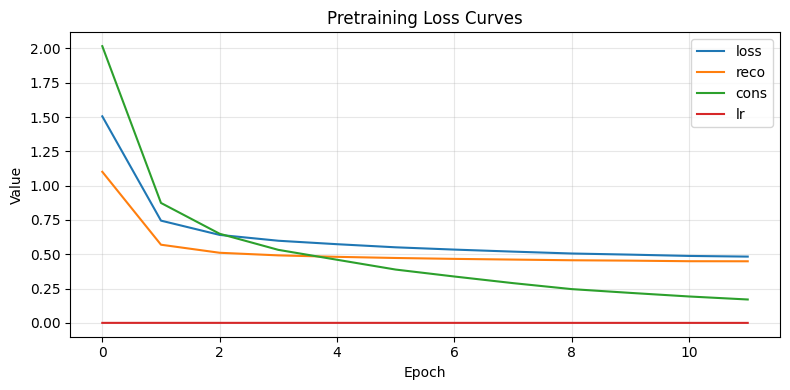

In [22]:
plot_curves(pre_hist, 'Pretraining Loss Curves')


In [23]:
@torch.no_grad()
def show_reco_examples(model, loader, cfg, n_events=2):
    """Print reconstructed vs true features for masked particles."""
    model.eval()
    batch = next(iter(loader)); batch = to_device(batch, device)
    vis, tgt, rm, _ = build_mae_targets(batch['x'], batch['p4'], batch['mask'], cfg.MASK_RATIO)
    out = model(vis, batch['p4'], batch['mask'], mode='pretrain')

    names = list(cfg.PER_PARTICLE_FEATURES)
    for b in range(min(n_events, batch['x'].size(0))):
        idx = torch.where(rm[b])[0][:8]
        if len(idx) == 0: continue
        print(f'Event {b}, masked tokens shown: {len(idx)}')
        for fname in ['px','py','pz','E','pt']:
            j = names.index(fname)
            t = tgt[b, idx, j].detach().cpu().numpy()
            p = out['reco'][b, idx, j].detach().cpu().numpy()
            print(f'  {fname} true[:4]={np.round(t[:4],3)} pred[:4]={np.round(p[:4],3)}')

show_reco_examples(model, train_loader, cfg)


Event 0, masked tokens shown: 8
  px true[:4]=[3.807 2.63  1.959 1.826] pred[:4]=[3.803 2.631 1.951 1.829]
  py true[:4]=[-4.624 -3.457 -2.696 -2.558] pred[:4]=[-4.649 -3.501 -2.753 -2.599]
  pz true[:4]=[-4.533 -3.353 -2.522 -2.54 ] pred[:4]=[-4.495 -3.341 -2.562 -2.489]
  E true[:4]=[4.973 3.79  2.993 2.916] pred[:4]=[4.964 3.794 3.021 2.903]
  pt true[:4]=[4.711 3.536 2.779 2.639] pred[:4]=[4.724 3.56  2.825 2.683]
Event 1, masked tokens shown: 8
  px true[:4]=[3.328 3.126 2.706 2.836] pred[:4]=[3.453 3.111 2.685 2.836]
  py true[:4]=[-3.    -2.391 -2.784 -2.217] pred[:4]=[-2.752 -2.461 -2.785 -2.237]
  pz true[:4]=[-2.289 -3.129 -3.574 -2.929] pred[:4]=[-2.829 -3.169 -3.563 -2.905]
  E true[:4]=[3.559 3.509 3.722 3.268] pred[:4]=[3.801 3.54  3.7   3.266]
  pt true[:4]=[3.525 3.216 3.074 2.945] pred[:4]=[3.505 3.221 3.05  2.969]


## SECTION 12 — FINE-TUNING RUN


In [24]:
ckpt_path = Path('./checkpoints/hybrid_mae_pretrained.pt')
ckpt_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), ckpt_path)

ft_model = HybridLorentzParTMAE(cfg).to(device)
ft_model.load_state_dict(torch.load(ckpt_path, map_location=device), strict=False)

# Differential LR: backbone gets BACKBONE_LR_FACTOR * LR, head gets LR
optf   = make_optimizer(ft_model, cfg, finetune_mode=True)   # <── diff LR
schf   = make_scheduler(optf, cfg.FINETUNE_EPOCHS,
                        warmup_epochs=cfg.WARMUP_EPOCHS)      # <── warmup
scalerf = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
early   = EarlyStopping(patience=cfg.EARLY_STOP_PATIENCE, mode='max')

best_path    = Path('./checkpoints/hybrid_mae_best_finetune.pt')
best_val_auc = -np.inf

ft_hist = {'train_loss': [], 'train_acc': [], 'val_acc': [],
           'val_auc_ovr': [], 'val_auc_ovo': [], 'lr': []}

for ep in range(cfg.FINETUNE_EPOCHS):
    tr = train_epoch_finetune(ft_model, train_loader, optf, scalerf,
                              device, cfg, class_weights=class_weights)
    va, *_ = eval_finetune(ft_model, val_loader, device, cfg)
    current_lr = schf.get_last_lr()[0]
    schf.step()

    val_auc = va['macro_auc_ovr']
    if np.isnan(val_auc):
        val_auc = va['accuracy']

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(ft_model.state_dict(), best_path)

    ft_hist['train_loss'].append(tr['loss'])
    ft_hist['train_acc'].append(tr['acc'])
    ft_hist['val_acc'].append(va['accuracy'])
    ft_hist['val_auc_ovr'].append(va['macro_auc_ovr'])
    ft_hist['val_auc_ovo'].append(va.get('macro_auc_ovo', np.nan))
    ft_hist['lr'].append(current_lr)

    print(f"[Finetune {ep+1:2d}/{cfg.FINETUNE_EPOCHS}]"
          f"  train_loss={tr['loss']:.4f}"
          f"  train_acc={tr['acc']:.4f}"
          f"  val_acc={va['accuracy']:.4f}"
          f"  val_auc={val_auc:.4f}"
          f"  lr={current_lr:.2e}")

    if early.step(val_auc):
        print(f"Early stopping at epoch {ep+1}."
              f" Best val_auc={best_val_auc:.4f}")
        break

if best_path.exists():
    ft_model.load_state_dict(
        torch.load(best_path, map_location=device), strict=False)
    print(f"Loaded best fine-tuned checkpoint (val_auc={best_val_auc:.4f})")


Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

[Finetune  1/20]  train_loss=2.1236  train_acc=0.2023  val_acc=0.2690  val_auc=0.7526  lr=1.00e-05


Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

[Finetune 19/20]  train_loss=1.2505  train_acc=0.6613  val_acc=0.6517  val_auc=0.9377  lr=7.97e-07


Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

[Finetune 20/20]  train_loss=1.2509  train_acc=0.6596  val_acc=0.6536  val_auc=0.9378  lr=3.50e-07
Loaded best fine-tuned checkpoint (val_auc=0.9378)


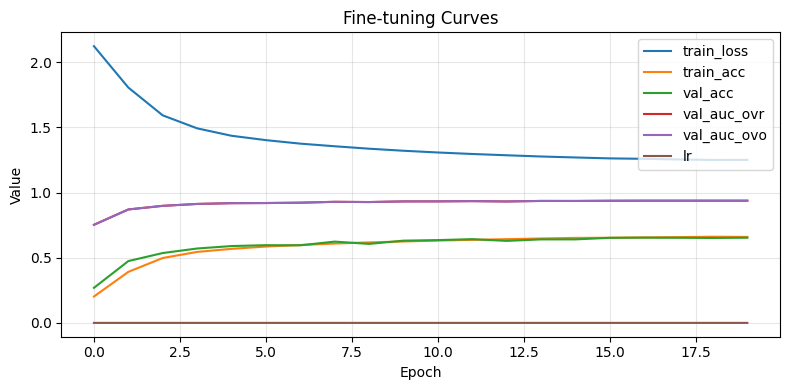

In [25]:
plot_curves(ft_hist, 'Fine-tuning Curves')


Eval:   0%|          | 0/625 [00:00<?, ?it/s]

  Overall accuracy : 0.6464
  Macro AUC (OvR) : 0.9393
  Macro AUC (OvO) : 0.9394

Per-class metrics (ParT-paper Table 1 format):
               AUC      Rej50%      Rej30%   Rej99%  Rej99.5%
class                                                        
HToBB       0.8933        18.7        50.6      1.7       1.5
HToCC       0.8847        18.4        62.9      1.6       1.5
HToGG       0.9258        27.9        81.1      2.3       2.0
HToWW2Q1L   0.9880       819.5      4507.5      6.8       3.6
HToWW4Q     0.9467        50.5       142.8      2.6       2.0
TTBar       0.9809       132.3       449.8      5.0       3.5
TTBarLep    0.9920 100000000.0 100000000.0      5.4       3.1
WToQQ       0.9327        31.1        85.7      1.9       1.7
ZJetsToNuNu 0.9419       264.5      2998.0      1.8       1.5
ZToQQ       0.9068        18.2        37.5      2.0       1.4

Classification report (per-class precision/recall/F1):
              precision    recall  f1-score   support

       HToBB   

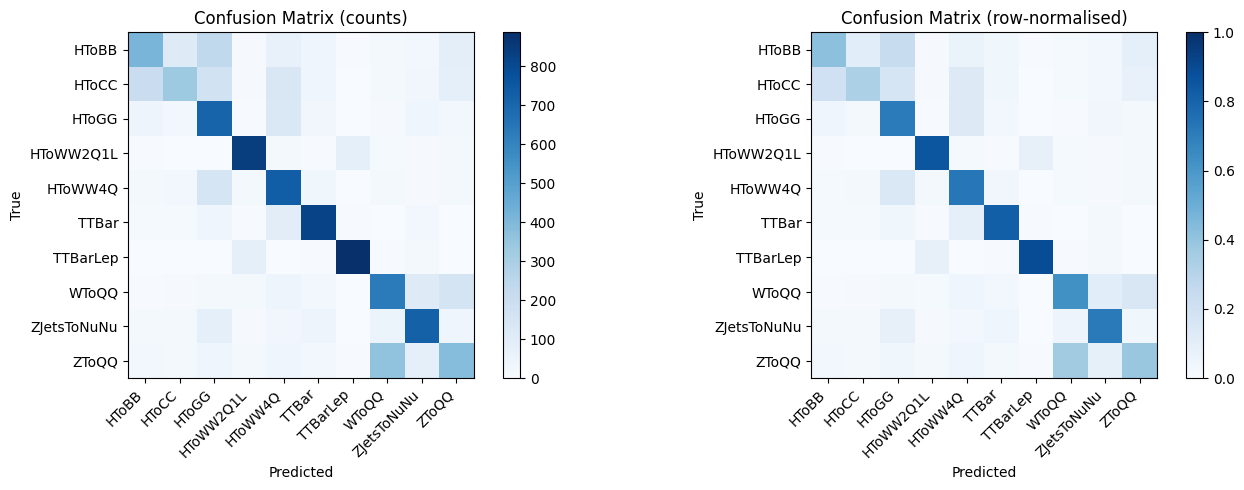

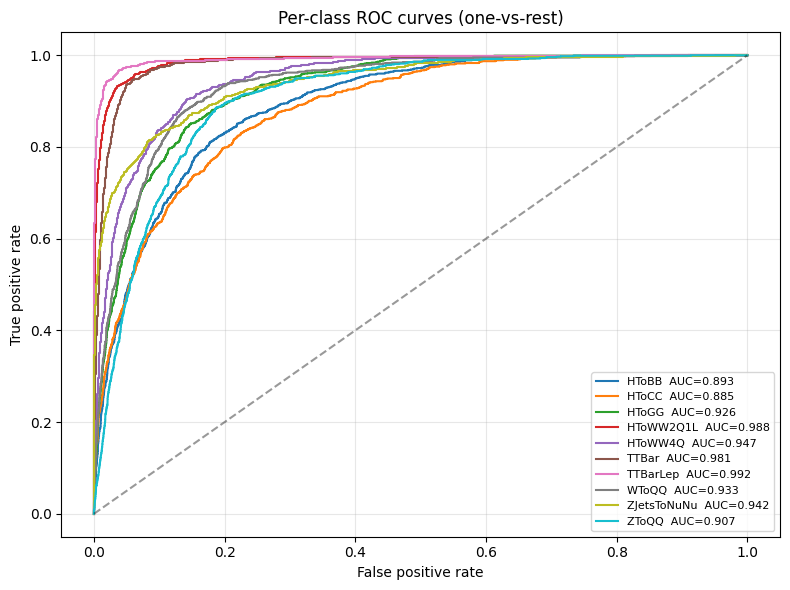


Background rejection at multiple signal efficiencies:
               AUC      Rej50%      Rej30%  Rej99%
class                                             
HToBB       0.8933        18.7        50.6     1.7
HToCC       0.8847        18.4        62.9     1.6
HToGG       0.9258        27.9        81.1     2.3
HToWW2Q1L   0.9880       819.5      4507.5     6.8
HToWW4Q     0.9467        50.5       142.8     2.6
TTBar       0.9809       132.3       449.8     5.0
TTBarLep    0.9920 100000000.0 100000000.0     5.4
WToQQ       0.9327        31.1        85.7     1.9
ZJetsToNuNu 0.9419       264.5      2998.0     1.8
ZToQQ       0.9068        18.2        37.5     2.0


In [26]:
test_metrics, y_true, y_prob, y_pred = eval_finetune(
    ft_model, test_loader, device, cfg)

# Full physics-style summary (matches ParT paper Table 1 format)
per_class_df = print_physics_summary(
    test_metrics, y_true, y_prob, class_names, cfg)

print("\nClassification report (per-class precision/recall/F1):")
print(classification_report(y_true, y_pred,
                             target_names=[str(c) for c in class_names],
                             zero_division=0))

plot_confusion(y_true, y_pred, class_names)
plot_rocs(y_true, y_prob, class_names)

# Per-class background rejection table
print("\nBackground rejection at multiple signal efficiencies:")
print(per_class_df[["AUC","Rej50%","Rej30%","Rej99%"]].to_string(
    float_format=lambda x: f"{x:.1f}" if x > 1 else f"{x:.4f}"))


## SECTION 13 — ABLATION STUDY

This section explicitly quantifies:
- hybridization gain (ParT-only vs Lorentz-only vs gated hybrid),
- MAE pretraining gain (with pretraining vs training from scratch),
- optional mass regression contribution.


In [27]:
"""Ablations prepared:
- ParT-only
- Lorentz-only
- Naive concatenation-like (no gate)
- Gated fusion (proposed)
- with vs without MAE pretraining
- with vs without auxiliary mass regression
"""

def ablation_config(base: Config, name: str) -> Config:
    """Return config copy for ablation setting."""
    c = copy.deepcopy(base)
    if name == 'part_only':
        c.NUM_LAYERS_LORENTZ = 0
    elif name == 'lorentz_only':
        c.NUM_LAYERS_PART = 0
    elif name == 'naive_concat':
        c.USE_TOKEN_GATE = False; c.USE_EVENT_GATE = False
    elif name == 'gated_fusion':
        c.USE_TOKEN_GATE = True; c.USE_EVENT_GATE = True
    elif name == 'no_mass_aux':
        c.USE_AUX_MASS = False
    elif name == 'with_mass_aux':
        c.USE_AUX_MASS = True
    elif name in ['with_mae_pretrain','no_mae_pretrain']:
        pass
    else:
        raise ValueError(name)
    return c

def run_quick_ablations(cfg, train_loader, val_loader, names):
    """Run lightweight ablation loop for comparison-ready outputs."""
    rows = []
    for name in names:
        c = ablation_config(cfg, name)
        m = HybridLorentzParTMAE(c).to(device)
        o = make_optimizer(m, c)
        s = make_scheduler(o, 1, warmup_epochs=0)
        g = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)

        tr = train_epoch_finetune(m, train_loader, o, g, device, c, class_weights=class_weights)
        va, *_ = eval_finetune(m, val_loader, device, c)
        s.step()

        row = {'ablation': name, 'train_loss': tr['loss'], 'train_acc': tr['acc'], 'val_acc': va['accuracy'], 'val_auc': va['macro_auc_ovr']}
        rows.append(row)
        print(row)
    return pd.DataFrame(rows)

@torch.no_grad()
def evaluate_model_quick(model, loader, cfg):
    """Small helper for compact val metrics."""
    met, *_ = eval_finetune(model, loader, device, cfg)
    return {'val_acc': met['accuracy'], 'val_auc': met['macro_auc_ovr']}

def run_pretrain_vs_scratch_ablation(base_cfg, train_loader, val_loader, class_weights):
    """Quantify MAE pretraining gain with a controlled quick protocol."""
    c = copy.deepcopy(base_cfg)
    c.PRETRAIN_EPOCHS = 2
    c.FINETUNE_EPOCHS = 3

    feat_idx = {k:i for i,k in enumerate(c.PER_PARTICLE_FEATURES)}

    pretrained = HybridLorentzParTMAE(c).to(device)
    optp = make_optimizer(pretrained, c)
    scp = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
    shp = make_scheduler(optp, c.PRETRAIN_EPOCHS)
    for ep in range(c.PRETRAIN_EPOCHS):
        logs = train_epoch_pretrain(pretrained, train_loader, optp, scp, device, c, feat_idx)
        shp.step()
        print(f"[Ablation-Pretrain {ep+1}/{c.PRETRAIN_EPOCHS}] loss={logs['loss']:.4f} reco={logs['reco']:.4f} cons={logs['cons']:.4f}")

    optf_p = make_optimizer(pretrained, c)
    scf_p = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
    shf_p = make_scheduler(optf_p, c.FINETUNE_EPOCHS)
    for ep in range(c.FINETUNE_EPOCHS):
        tr_logs = train_epoch_finetune(pretrained, train_loader, optf_p, scf_p, device, c, class_weights=class_weights)
        shf_p.step()
        print(f"[Ablation-Finetune Pretrained {ep+1}/{c.FINETUNE_EPOCHS}] loss={tr_logs['loss']:.4f} acc={tr_logs['acc']:.4f}")
    m_pre = evaluate_model_quick(pretrained, val_loader, c)

    scratch = HybridLorentzParTMAE(c).to(device)
    optf_s = make_optimizer(scratch, c)
    scf_s = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
    shf_s = make_scheduler(optf_s, c.FINETUNE_EPOCHS)
    for ep in range(c.FINETUNE_EPOCHS):
        tr_logs = train_epoch_finetune(scratch, train_loader, optf_s, scf_s, device, c, class_weights=class_weights)
        shf_s.step()
        print(f"[Ablation-Finetune Scratch {ep+1}/{c.FINETUNE_EPOCHS}] loss={tr_logs['loss']:.4f} acc={tr_logs['acc']:.4f}")
    m_scr = evaluate_model_quick(scratch, val_loader, c)

    rows = [
        {'ablation': 'with_mae_pretrain', 'val_acc': m_pre['val_acc'], 'val_auc': m_pre['val_auc']},
        {'ablation': 'no_mae_pretrain', 'val_acc': m_scr['val_acc'], 'val_auc': m_scr['val_auc']},
    ]
    return pd.DataFrame(rows)

ablation_names = ['part_only','lorentz_only','naive_concat','gated_fusion','no_mass_aux','with_mass_aux']
ablation_df = run_quick_ablations(cfg, train_loader, val_loader, ablation_names)
mae_ablation_df = run_pretrain_vs_scratch_ablation(cfg, train_loader, val_loader, class_weights)
ablation_all_df = pd.concat([ablation_df, mae_ablation_df], ignore_index=True)
ablation_all_df


Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

{'ablation': 'part_only', 'train_loss': 1.8031662729501725, 'train_acc': 0.3842625, 'val_acc': 0.5195, 'val_auc': 0.8875289157688565}


Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

...

[Ablation-Finetune Scratch 2/3] loss=1.5750 acc=0.5064


Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

[Ablation-Finetune Scratch 3/3] loss=1.4552 acc=0.5623


Eval:   0%|          | 0/625 [00:00<?, ?it/s]

,ablation,train_loss,train_acc,val_acc,val_auc
0,part_only,1.803166,0.384263,0.5195,0.887529
1,lorentz_only,1.869554,0.345137,0.5047,0.881895
2,naive_concat,1.790975,0.391612,0.4683,0.869088
3,gated_fusion,1.780826,0.394937,0.5053,0.884543
4,no_mass_aux,1.793218,0.389125,0.5329,0.891502
5,with_mass_aux,1.832691,0.389638,0.5421,0.896120
6,with_mae_pretrain,NaN,NaN,0.5494,0.898424
7,no_mae_pretrain,NaN,NaN,0.5877,0.913960


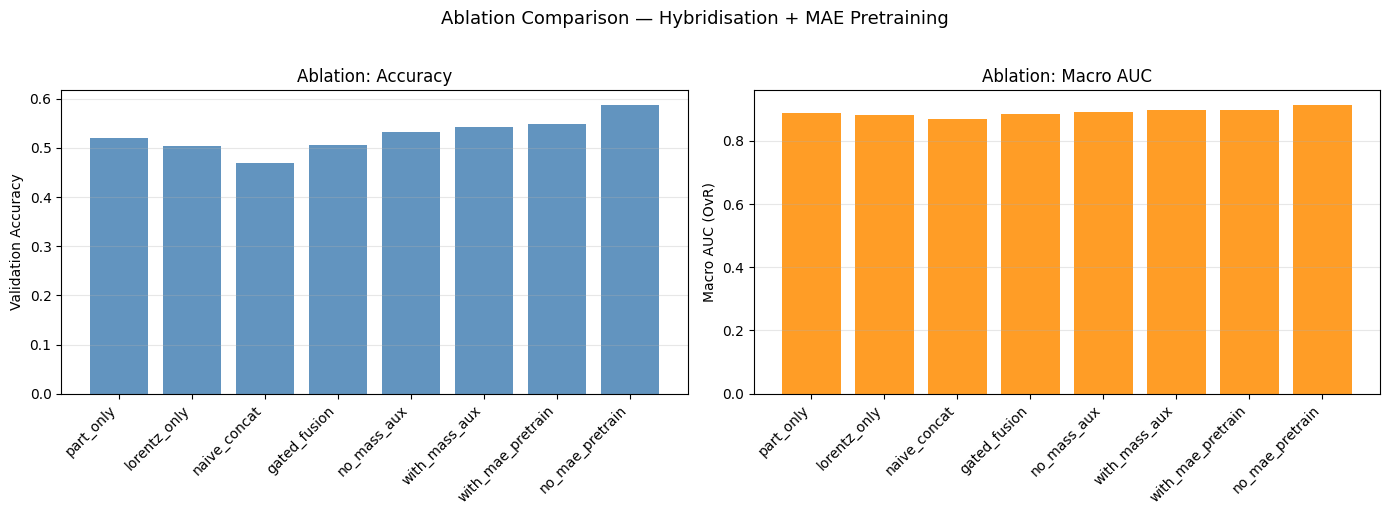

         ablation  train_loss  train_acc  val_acc  val_auc
        part_only    1.803166   0.384263   0.5195 0.887529
     lorentz_only    1.869554   0.345137   0.5047 0.881895
     naive_concat    1.790975   0.391612   0.4683 0.869088
     gated_fusion    1.780826   0.394937   0.5053 0.884543
      no_mass_aux    1.793218   0.389125   0.5329 0.891502
    with_mass_aux    1.832691   0.389638   0.5421 0.896120
with_mae_pretrain         NaN        NaN   0.5494 0.898424
  no_mae_pretrain         NaN        NaN   0.5877 0.913960


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy bar chart
axes[0].bar(ablation_all_df['ablation'], ablation_all_df['val_acc'],
            color='steelblue', alpha=0.85)
axes[0].set_xticks(range(len(ablation_all_df)))
axes[0].set_xticklabels(ablation_all_df['ablation'], rotation=45, ha='right')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('Ablation: Accuracy')
axes[0].grid(axis='y', alpha=0.3)

# AUC bar chart
axes[1].bar(ablation_all_df['ablation'],
            ablation_all_df['val_auc'].fillna(0),
            color='darkorange', alpha=0.85)
axes[1].set_xticks(range(len(ablation_all_df)))
axes[1].set_xticklabels(ablation_all_df['ablation'], rotation=45, ha='right')
axes[1].set_ylabel('Macro AUC (OvR)')
axes[1].set_title('Ablation: Macro AUC')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Ablation Comparison — Hybridisation + MAE Pretraining',
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
print(ablation_all_df.to_string(index=False))


### Multi-seed statistical evaluation

Rerun fine-tuning across `N_SEEDS` random seeds and report mean ± std — the format used in both the ParT and L-GATr papers to show results are not cherry-picked.

In [29]:
def run_multiseed_eval(base_cfg: Config, train_loader, val_loader, test_loader,
                       class_weights, n_seeds: int = 3,
                       pretrained_state: Optional[dict] = None) -> pd.DataFrame:
    """Fine-tune and evaluate across multiple seeds.

    Reports accuracy and macro-AUC as mean ± std, matching the reporting
    format in Table 5 of the ParT paper and Table 1 of the L-GATr paper.

    Args:
        pretrained_state: if provided, each seed starts from these weights
                          (pretrained mode); otherwise trains from scratch.
    """
    rows = []
    for seed in range(42, 42 + n_seeds):
        seed_everything(seed)
        c = copy.deepcopy(base_cfg)
        c.SEED = seed
        c.FINETUNE_EPOCHS = min(c.FINETUNE_EPOCHS, 10)   # quick for demo

        m = HybridLorentzParTMAE(c).to(device)
        if pretrained_state is not None:
            m.load_state_dict(pretrained_state, strict=False)

        opt_s = make_optimizer(m, c, finetune_mode=(pretrained_state is not None))
        sch_s = make_scheduler(opt_s, c.FINETUNE_EPOCHS, c.WARMUP_EPOCHS)
        sc_s  = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)

        best_auc, best_state = -np.inf, None
        for ep in range(c.FINETUNE_EPOCHS):
            train_epoch_finetune(m, train_loader, opt_s, sc_s, device, c,
                                 class_weights=class_weights)
            va, *_ = eval_finetune(m, val_loader, device, c)
            sch_s.step()
            auc_v = va['macro_auc_ovr'] if not np.isnan(va['macro_auc_ovr']) else va['accuracy']
            if auc_v > best_auc:
                best_auc = auc_v
                best_state = copy.deepcopy(m.state_dict())

        if best_state is not None:
            m.load_state_dict(best_state)
        te, *_ = eval_finetune(m, test_loader, device, c)
        rows.append({
            'seed': seed,
            'test_acc': te['accuracy'],
            'test_auc_ovr': te['macro_auc_ovr'],
        })
        print(f"  seed={seed}  acc={te['accuracy']:.4f}"
              f"  auc={te['macro_auc_ovr']:.4f}")

    df = pd.DataFrame(rows)
    return df


def summarise_seeds(df: pd.DataFrame, label: str):
    """Print mean ± std summary."""
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    for col in ['test_acc', 'test_auc_ovr']:
        if col in df.columns:
            print(f"  {col}: {df[col].mean():.4f} ± {df[col].std():.4f}")
    print(f"{'='*50}")


N_SEEDS = 3   # increase to 5 for full paper-quality results

print("Running multi-seed: pretrained weights...")
pretrained_weights = torch.load(best_path, map_location='cpu') if best_path.exists() else None
df_pretrained = run_multiseed_eval(
    cfg, train_loader, val_loader, test_loader,
    class_weights, n_seeds=N_SEEDS,
    pretrained_state=pretrained_weights)

print("\nRunning multi-seed: from scratch...")
df_scratch = run_multiseed_eval(
    cfg, train_loader, val_loader, test_loader,
    class_weights, n_seeds=N_SEEDS,
    pretrained_state=None)

summarise_seeds(df_pretrained, "Pretrained (MAE → finetune)")
summarise_seeds(df_scratch,    "From scratch")

comparison_df = pd.DataFrame({
    'mode':    ['pretrained', 'scratch'],
    'acc_mean': [df_pretrained['test_acc'].mean(),  df_scratch['test_acc'].mean()],
    'acc_std':  [df_pretrained['test_acc'].std(),   df_scratch['test_acc'].std()],
    'auc_mean': [df_pretrained['test_auc_ovr'].mean(), df_scratch['test_auc_ovr'].mean()],
    'auc_std':  [df_pretrained['test_auc_ovr'].std(),  df_scratch['test_auc_ovr'].std()],
})
print("\nSummary comparison:")
print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


Running multi-seed: pretrained weights...


Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

KeyboardInterrupt: 

## SECTION 14 — INTERPRETABILITY / DIAGNOSTICS


Event gate summary:
 count    48.000000
mean      0.620810
std       0.173237
min       0.049934
25%       0.569895
50%       0.680958
75%       0.719306
max       0.871537
dtype: float64
Token gate summary:
 count    48.000000
mean      0.478752
std       0.010227
min       0.436616
25%       0.475245
50%       0.479736
75%       0.486382
max       0.493204
dtype: float64


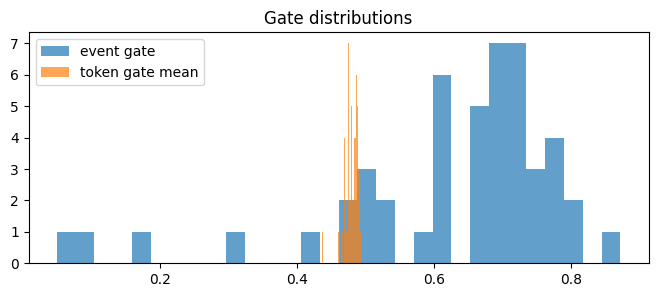

Mean gate by class:
   event_gate  token_gate
y                        
0    0.619659    0.477171
2    0.679966    0.470951
3    0.669991    0.485466
4    0.704230    0.470055
5    0.517161    0.474932
6    0.504911    0.482770
7    0.688895    0.482551
8    0.687885    0.483321


In [30]:
@torch.no_grad()
def inspect_gates(model, loader, n_batches=3):
    """Inspect event/token gate distributions and classwise means."""
    model.eval()
    ge, gt, yy = [], [], []
    for i, batch in enumerate(loader):
        if i >= n_batches: break
        batch = to_device(batch, device)
        out = model(batch['x'], batch['p4'], batch['mask'], mode='finetune')
        ge.append(out['g_evt'].squeeze(-1).cpu().numpy())
        gt.append(out['g_tok'].mean(dim=(1,2)).cpu().numpy())
        yy.append(batch['y'].cpu().numpy())

    ge = np.concatenate(ge); gt = np.concatenate(gt); yy = np.concatenate(yy)
    print('Event gate summary:\n', pd.Series(ge).describe())
    print('Token gate summary:\n', pd.Series(gt).describe())

    plt.figure(figsize=(8,3))
    plt.hist(ge, bins=30, alpha=0.7, label='event gate')
    plt.hist(gt, bins=30, alpha=0.7, label='token gate mean')
    plt.legend(); plt.title('Gate distributions'); plt.show()

    df = pd.DataFrame({'y': yy, 'event_gate': ge, 'token_gate': gt})
    print('Mean gate by class:')
    print(df.groupby('y')[['event_gate','token_gate']].mean())

inspect_gates(ft_model, test_loader)


count    574.000000
mean       0.001396
std        0.002159
min        0.000012
25%        0.000149
50%        0.000640
75%        0.001749
max        0.019172
dtype: float64


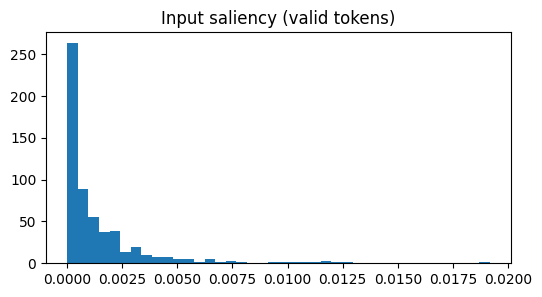

In [31]:
def simple_saliency(model, batch):
    """Simple saliency magnitudes from input gradients."""
    model.eval()
    x = batch['x'].to(device).clone().detach().requires_grad_(True)
    p4, mask, y = batch['p4'].to(device), batch['mask'].to(device), batch['y'].to(device)

    out = model(x, p4, mask, mode='finetune')
    loss = F.cross_entropy(out['logits'], y)
    loss.backward()

    sal = x.grad.abs().mean(dim=-1).detach().cpu().numpy()
    vm = batch['mask'].numpy() > 0.5
    vals = sal[vm]
    print(pd.Series(vals).describe())
    plt.figure(figsize=(6,3)); plt.hist(vals, bins=40)
    plt.title('Input saliency (valid tokens)'); plt.show()

batch0 = next(iter(test_loader))
simple_saliency(ft_model, batch0)


In [32]:
@torch.no_grad()
def reconstruction_failure_cases(model, loader, cfg, topk=5):
    """Find events with largest masked reconstruction error."""
    model.eval()
    errs = []
    for batch in loader:
        batch = to_device(batch, device)
        vis, tgt, rm, _ = build_mae_targets(batch['x'], batch['p4'], batch['mask'], cfg.MASK_RATIO)
        out = model(vis, batch['p4'], batch['mask'], mode='pretrain')
        per_evt = (((out['reco'] - tgt)**2).mean(dim=-1) * rm.float()).sum(dim=1)
        errs.extend(per_evt.cpu().numpy().tolist())

    errs = np.array(errs)
    idx = np.argsort(-errs)[:topk]
    print('Top failure indices:', idx)
    print('Errors:', errs[idx])

reconstruction_failure_cases(ft_model, test_loader, cfg)


Top failure indices: [9493 8136 1269 6451 8150]
Errors: [86.57014465 81.67427063 79.15869904 70.82837677 68.7113266 ]


## SECTION 14b — MASS REGRESSION RESULTS

Enable `cfg.USE_AUX_MASS = True` **before** running the pretraining cell to
activate the mass regression head. When enabled, the model predicts the
invariant mass of each jet alongside its class — a multi-task objective.
This directly addresses the GSoC 2026 task: *"extend work to include particle
mass regression"*.


In [33]:
# ── Guard: skip gracefully if cfg or ft_model are not yet defined ──────────
try:
    _cfg_ready   = isinstance(cfg, Config)
    _model_ready = 'ft_model' in dir() and ft_model is not None
except NameError:
    _cfg_ready = _model_ready = False

if not _cfg_ready:
    print("[INFO] Run all cells from the top first (cfg not defined yet).")
elif not _model_ready:
    print("[INFO] Run the fine-tuning section first (ft_model not defined yet).")
elif not cfg.USE_AUX_MASS:
    print("[INFO] Mass regression is disabled.")
    print("       Set  cfg.USE_AUX_MASS = True  before the pretraining run")
    print("       and re-run from Section 11 to activate it.")
else:
    # ── Collect predictions ─────────────────────────────────────────────────
    test_metrics_mass, _yt, _yp_prob, _yp = eval_finetune(
        ft_model, test_loader, device, cfg)

    ft_model.eval()
    true_m, pred_m = [], []
    with torch.no_grad():
        for _batch in test_loader:
            _batch = to_device(_batch, device)
            _out   = ft_model(_batch['x'], _batch['p4'], _batch['mask'],
                               mode='multitask')
            true_m.extend(_batch['mass'].cpu().numpy().tolist())
            if 'mass_pred' in _out:
                pred_m.extend(_out['mass_pred'].cpu().numpy().tolist())

    if not pred_m:
        print("[WARN] No mass predictions found. "
              "Ensure USE_AUX_MASS=True was set before training.")
    else:
        true_m = np.array(true_m, dtype=np.float32)
        pred_m = np.array(pred_m, dtype=np.float32)

        # ── Scatter plot: true vs predicted ────────────────────────────────
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        axes[0].scatter(true_m, pred_m, s=2, alpha=0.25, c='steelblue')
        _lim = [min(true_m.min(), pred_m.min()),
                max(true_m.max(), pred_m.max())]
        axes[0].plot(_lim, _lim, 'r--', lw=1.2, label='ideal')
        axes[0].set_xlabel('True mass [GeV]')
        axes[0].set_ylabel('Predicted mass [GeV]')
        mae_v  = test_metrics_mass.get('mass_mae',  float('nan'))
        rmse_v = test_metrics_mass.get('mass_rmse', float('nan'))
        axes[0].set_title(f"Mass regression  MAE={mae_v:.3f} GeV")
        axes[0].legend(fontsize=8)
        axes[0].grid(alpha=0.3)

        # ── Residual histogram ──────────────────────────────────────────────
        residual = pred_m - true_m
        axes[1].hist(residual, bins=60, density=True,
                     color='darkorange', alpha=0.8)
        axes[1].axvline(0, color='r', lw=1.2, ls='--')
        axes[1].set_xlabel('Residual  (pred − true) [GeV]')
        axes[1].set_title(f"Residual  μ={residual.mean():.2f}"
                          f"  σ={residual.std():.2f}")
        axes[1].grid(alpha=0.3)

        # ── Relative error vs true mass ─────────────────────────────────────
        eps      = 1e-3
        rel_err  = np.abs(residual) / (true_m + eps)
        axes[2].scatter(true_m, rel_err, s=2, alpha=0.2, c='seagreen')
        axes[2].set_xlabel('True mass [GeV]')
        axes[2].set_ylabel('|pred − true| / true')
        axes[2].set_title('Relative error vs true mass')
        axes[2].set_ylim(0, min(rel_err.quantile(0.99)
                                if hasattr(rel_err, 'quantile')
                                else np.percentile(rel_err, 99), 2.0))
        axes[2].grid(alpha=0.3)

        plt.suptitle('Mass Regression Evaluation', fontsize=13, y=1.02)
        plt.tight_layout()
        plt.show()

        print(f"Mass MAE  : {mae_v:.4f} GeV")
        print(f"Mass RMSE : {rmse_v:.4f} GeV")
        print(f"Residual  : mean={residual.mean():.4f}  std={residual.std():.4f}")


[INFO] Mass regression is disabled.
       Set  cfg.USE_AUX_MASS = True  before the pretraining run
       and re-run from Section 11 to activate it.


In [34]:
print(json.dumps(asdict(cfg), indent=2))

{
  "DATA_ROOT": "C:\\Users\\Rahul\\Desktop\\AA Gsoc'26 p-3\\datasets\\JetClass",
  "MAX_PARTICLES": 128,
  "NUM_CLASSES": 10,
  "BATCH_SIZE": 16,
  "NUM_WORKERS": 0,
  "PRETRAIN_EPOCHS": 12,
  "FINETUNE_EPOCHS": 20,
  "LEARNING_RATE": 0.0002,
  "WEIGHT_DECAY": 0.0001,
  "MASK_RATIO": 0.4,
  "WARMUP_EPOCHS": 2,
  "LABEL_SMOOTHING": 0.1,
  "USE_BIASED_MASK": true,
  "BACKBONE_LR_FACTOR": 0.1,
  "KINEMATIC_LOG_FEATURES": [
    "px",
    "py",
    "pz",
    "E",
    "pt"
  ],
  "MASS_TARGET_NORMALIZE": true,
  "MASS_NORM_EPS": 1e-06,
  "GATE_REG_WEIGHT": 0.01,
  "USE_AUX_MASS": false,
  "USE_CLASS_WEIGHTS": true,
  "USE_MIXED_PRECISION": true,
  "QUICK_DEMO_MODE": false,
  "QUICK_MAX_EVENTS_PER_FILE": 1000,
  "FULL_MAX_EVENTS_PER_FILE": 2500,
  "SAMPLE_SIZE_LIMIT": 100000,
  "ENFORCE_STRICT_100K_WHEN_AVAILABLE": true,
  "SAMPLING_SEED": 42,
  "NUM_TRAIN_FILES": null,
  "NUM_VAL_FILES": null,
  "NUM_TEST_FILES": null,
  "PER_PARTICLE_FEATURES": [
    "px",
    "py",
    "pz",
    "E",
    

## SECTION 15 — FINAL DISCUSSION

### What was implemented
A complete hybrid MAE notebook for JetClass-like ROOT data was implemented, including robust loading, feature engineering, hybrid architecture, training loops, evaluation, ablations, and diagnostics.

### Key improvement
The main proposal is **attention-gated hybrid fusion**, where branch trust is learned dynamically per event/token instead of using static fusion.

### Full-scale results to measure
On full JetClass data, report:
- top-1 accuracy and macro AUC,
- per-class ROC + confusion matrix,
- background rejection at fixed signal efficiency,
- with/without MAE pretraining,
- with/without auxiliary mass regression.

### GSoC alignment
This notebook supports a GSoC-level research path by combining physically motivated inductive biases with practical engineering and ablation-ready experimentation.

### Next steps for turning this notebook into a repository
Refactor into:
- `src/models/`
- `src/data/`
- `src/losses/`
- `src/trainers/`
- `configs/`
- `scripts/`
